## 目标: 
构建一个稳健的机器学习模型，以准确预测客户是否会流失。

### 具体的项目目标  
利用高级特征工程技术提升预测性能
应用嵌套交叉验证来实施防数据泄露的目标编码
利用统计和基于分布的特征来捕捉隐藏关系
使用 XGBoost 并以 AUC 作为评估指标来优化模型性能
为未见过的测试数据生成可靠的预测结果 

- [ ] **任务：**  
  二分类问题（预测客户是否会流失 Churn）

- [ ] **核心策略：**  
  利用大量外部数据（Original Dataset）和高级特征工程技术...

In [8]:
import numpy as np
import pandas as pd
import warnings
import gc
import time
from itertools import combinations

from sklearn.metrics import *

from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import TargetEncoder
from xgboost import XGBClassifier
from sklearn.metrics import roc_curve, auc, precision_recall_curve

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# Display Markdown
from IPython.display import display, Markdown
from matplotlib.colors import LinearSegmentedColormap

sns.set_theme(style="whitegrid", palette="muted")
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 100)

display(Markdown("### <span style='color:#0f3460; font-weight:600;'> Libraries Loaded!</span>"))

### <span style='color:#0f3460; font-weight:600;'> Libraries Loaded!</span>

## 加载数据

In [9]:
#加载数据
display(Markdown("## <span style='color:#0f3460; font-weight:600;'>Data Loading</span>"))

train = pd.read_csv('C:/Users/GaoTing/Desktop/train.csv')
test  = pd.read_csv('C:/Users/GaoTing/Desktop/test.csv')
orig  = pd.read_csv('C:/Users/GaoTing/Desktop/WA_Fn-UseC_-Telco-Customer-Churn.csv')

#数据预览
display(Markdown("## <span style='color:#0f3460; font-weight:600;'>Training Data Loaded</span>"))
display(Markdown(f"**Rows:** {train.shape[0]}, **Columns:** {train.shape[1]}"))
display(train.head(3))

display(Markdown("## <span style='color:#0f3460; font-weight:600;'>Test Data Loaded</span>"))
display(Markdown(f"**Rows:** {test.shape[0]}, **Columns:** {test.shape[1]}"))
display(test.head(3))

display(Markdown("## <span style='color:#0f3460; font-weight:600;'>Original Data Loaded</span>"))
display(Markdown(
    f"**Original shape:** <span style='color:#0f3460; font-weight:600;'>{orig.shape}</span>"
))


## <span style='color:#0f3460; font-weight:600;'>Data Loading</span>

## <span style='color:#0f3460; font-weight:600;'>Training Data Loaded</span>

**Rows:** 594194, **Columns:** 21

,id,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,Male,0,Yes,Yes,29,Yes,No,DSL,Yes,No,Yes,Yes,No,No,One year,Yes,Mailed check,60.1,1653.85,No
1,1,Male,0,Yes,Yes,58,Yes,No,DSL,Yes,Yes,No,Yes,Yes,No,Two year,No,Credit card (automatic),69.5,3778.20,No
2,2,Male,0,Yes,No,58,Yes,Yes,Fiber optic,No,Yes,No,No,Yes,Yes,Month-to-month,Yes,Electronic check,100.4,5841.35,No


## <span style='color:#0f3460; font-weight:600;'>Test Data Loaded</span>

**Rows:** 254655, **Columns:** 20

,id,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
0,594194,Female,0,Yes,No,72,Yes,Yes,Fiber optic,Yes,Yes,Yes,Yes,Yes,Yes,Two year,Yes,Electronic check,115.55,8061.50
1,594195,Female,0,Yes,No,71,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Bank transfer (automatic),19.80,1336.50
2,594196,Male,0,No,No,12,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Bank transfer (automatic),55.55,633.55


## <span style='color:#0f3460; font-weight:600;'>Original Data Loaded</span>

**Original shape:** <span style='color:#0f3460; font-weight:600;'>(7043, 21)</span>

# 进行探索性数据分析（EDA.Exploratory Data Analysis）
### 自动分析每个特征的分布和与流失的关系
* [1] 数据清洗
* [2] 自动识别特征类型
* [3] 为每个特征生成两张图
  * 左图：训练集、测试集、原始数据的分布对比 → 检查数据是否一致
  * 右图：流失客户 vs 未流失客户的箱线图 → 看该特征能否区分两类客户

📊 EDA REPORT
数值特征 (3): ['tenure', 'MonthlyCharges', 'TotalCharges']
类别特征 (16): ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'SeniorCitizen']

--------------------------------------------------
特征: GENDER
类型: 类别型
  Train -> 唯一值: 2 | 缺失值: 0 (0.00%)
  Test -> 唯一值: 2 | 缺失值: 0 (0.00%)
  Original -> 唯一值: 2 | 缺失值: 0 (0.00%)


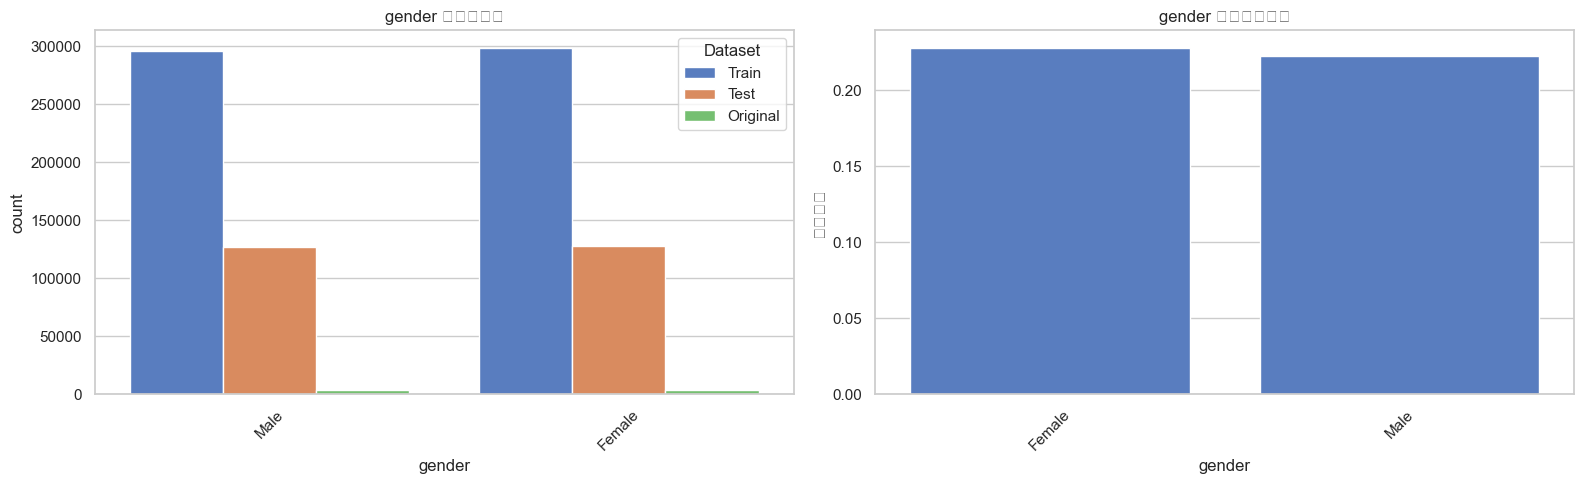

--------------------------------------------------
特征: SENIORCITIZEN
类型: 类别型
  Train -> 唯一值: 2 | 缺失值: 0 (0.00%)
  Test -> 唯一值: 2 | 缺失值: 0 (0.00%)
  Original -> 唯一值: 2 | 缺失值: 0 (0.00%)


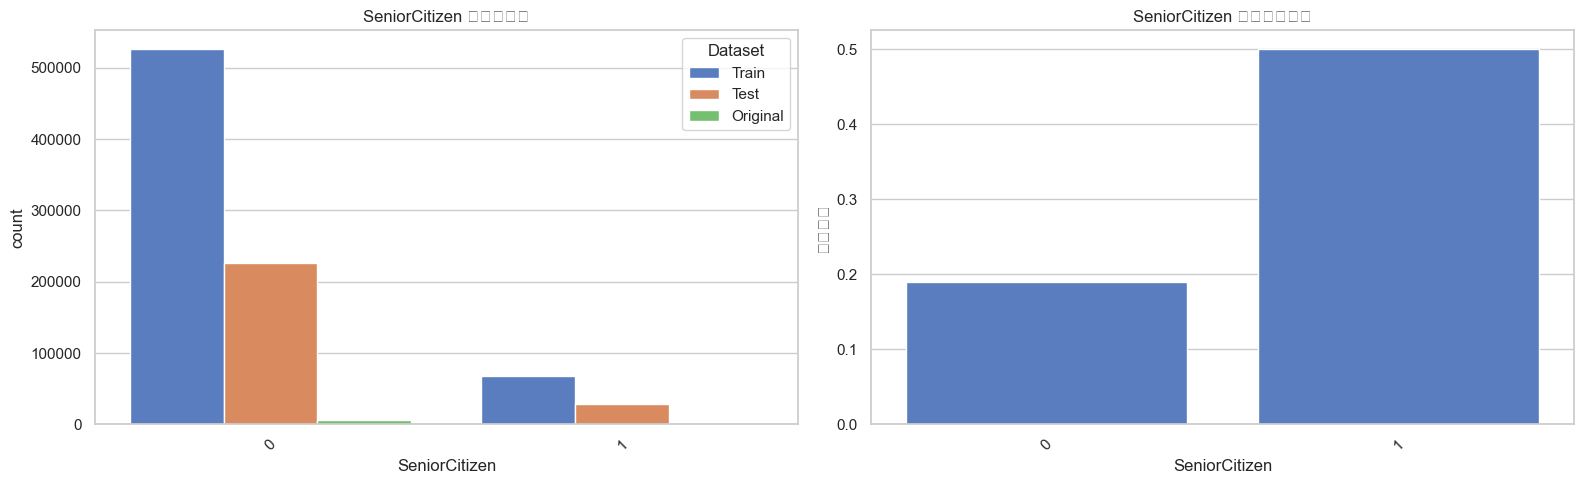

--------------------------------------------------
特征: PARTNER
类型: 类别型
  Train -> 唯一值: 2 | 缺失值: 0 (0.00%)
  Test -> 唯一值: 2 | 缺失值: 0 (0.00%)
  Original -> 唯一值: 2 | 缺失值: 0 (0.00%)


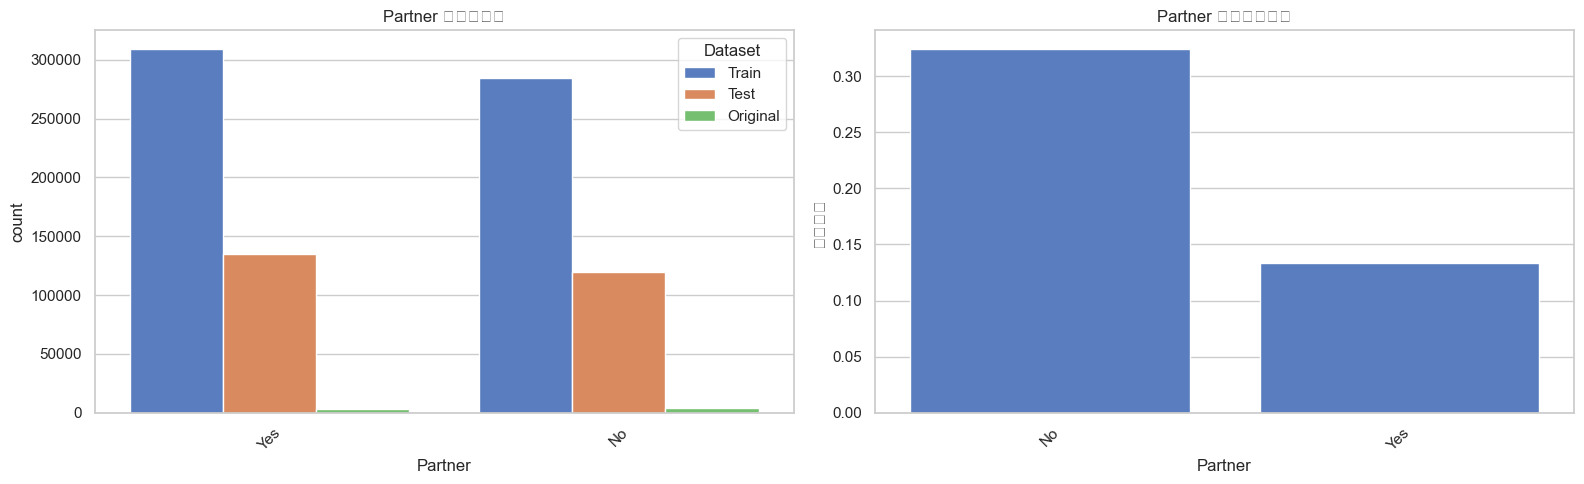

--------------------------------------------------
特征: DEPENDENTS
类型: 类别型
  Train -> 唯一值: 2 | 缺失值: 0 (0.00%)
  Test -> 唯一值: 2 | 缺失值: 0 (0.00%)
  Original -> 唯一值: 2 | 缺失值: 0 (0.00%)


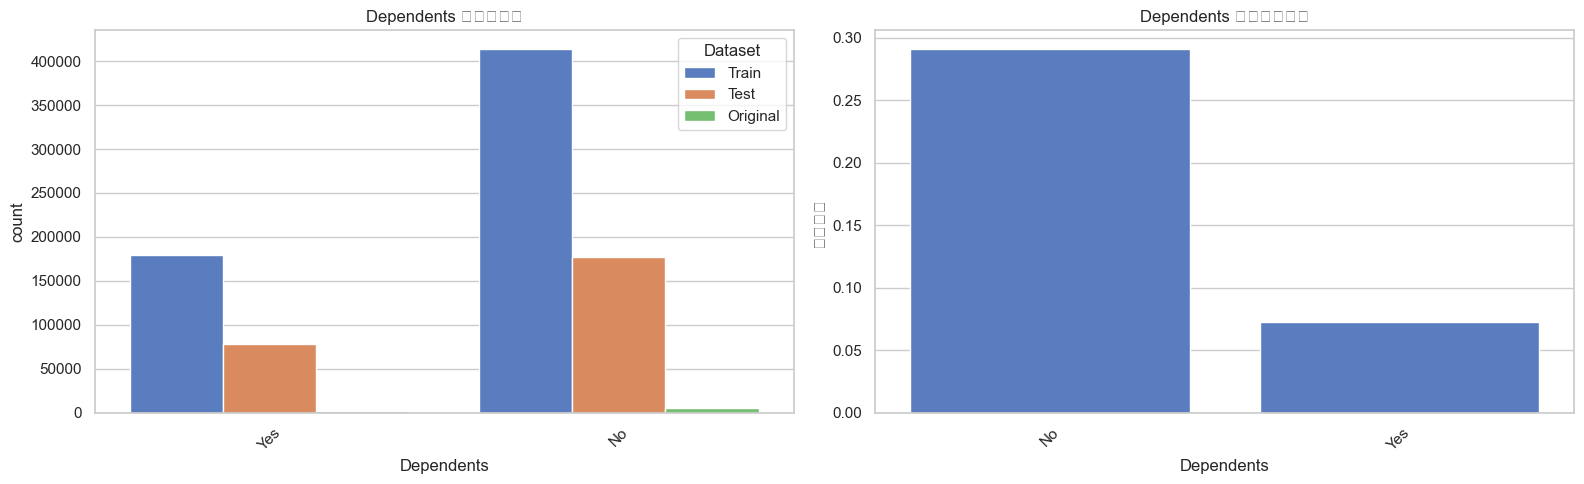

--------------------------------------------------
特征: TENURE
类型: 数值型
  Train -> 唯一值: 72 | 缺失值: 0 (0.00%)
  Test -> 唯一值: 72 | 缺失值: 0 (0.00%)
  Original -> 唯一值: 73 | 缺失值: 0 (0.00%)


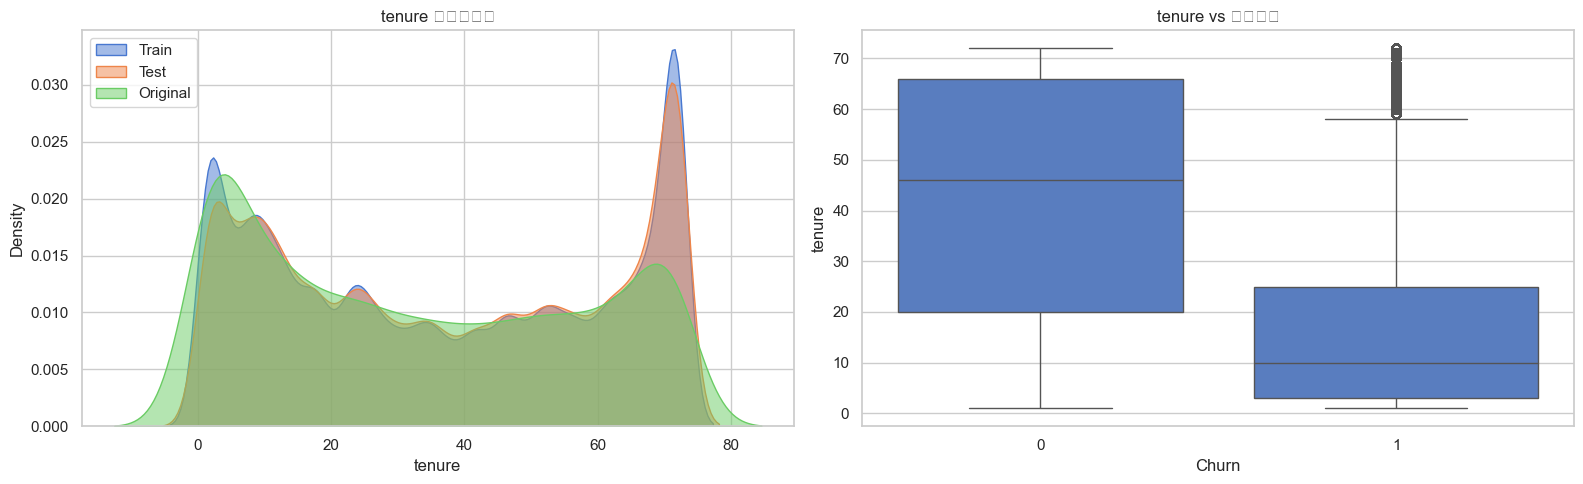

--------------------------------------------------
特征: PHONESERVICE
类型: 类别型
  Train -> 唯一值: 2 | 缺失值: 0 (0.00%)
  Test -> 唯一值: 2 | 缺失值: 0 (0.00%)
  Original -> 唯一值: 2 | 缺失值: 0 (0.00%)


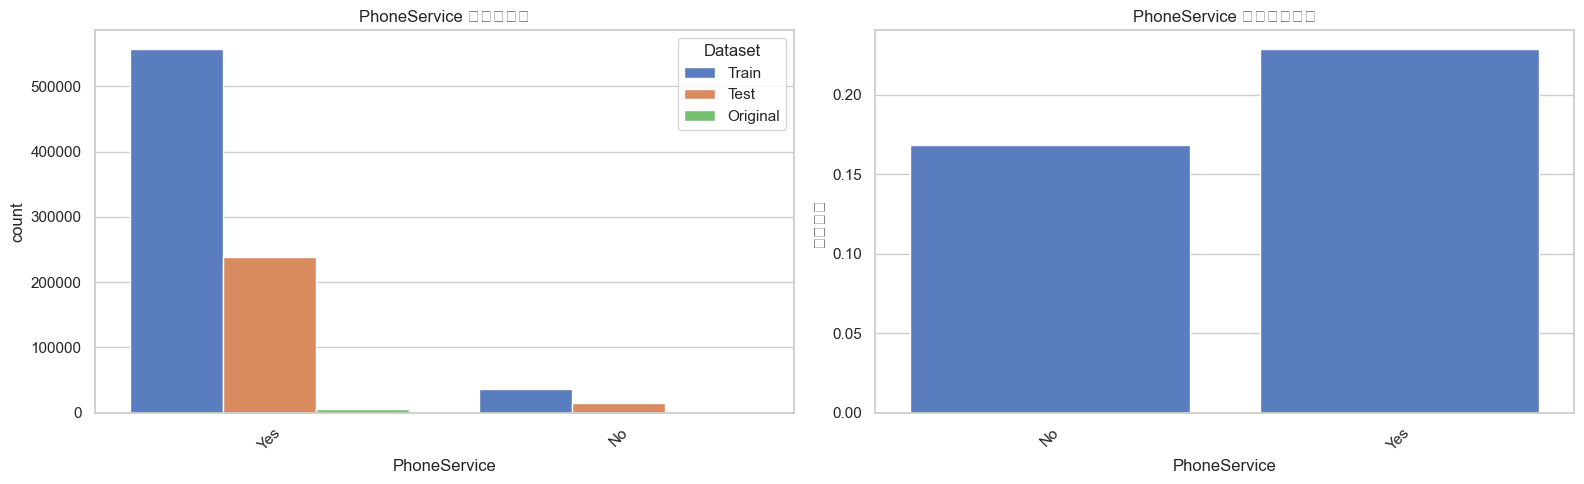

--------------------------------------------------
特征: MULTIPLELINES
类型: 类别型
  Train -> 唯一值: 3 | 缺失值: 0 (0.00%)
  Test -> 唯一值: 3 | 缺失值: 0 (0.00%)
  Original -> 唯一值: 3 | 缺失值: 0 (0.00%)


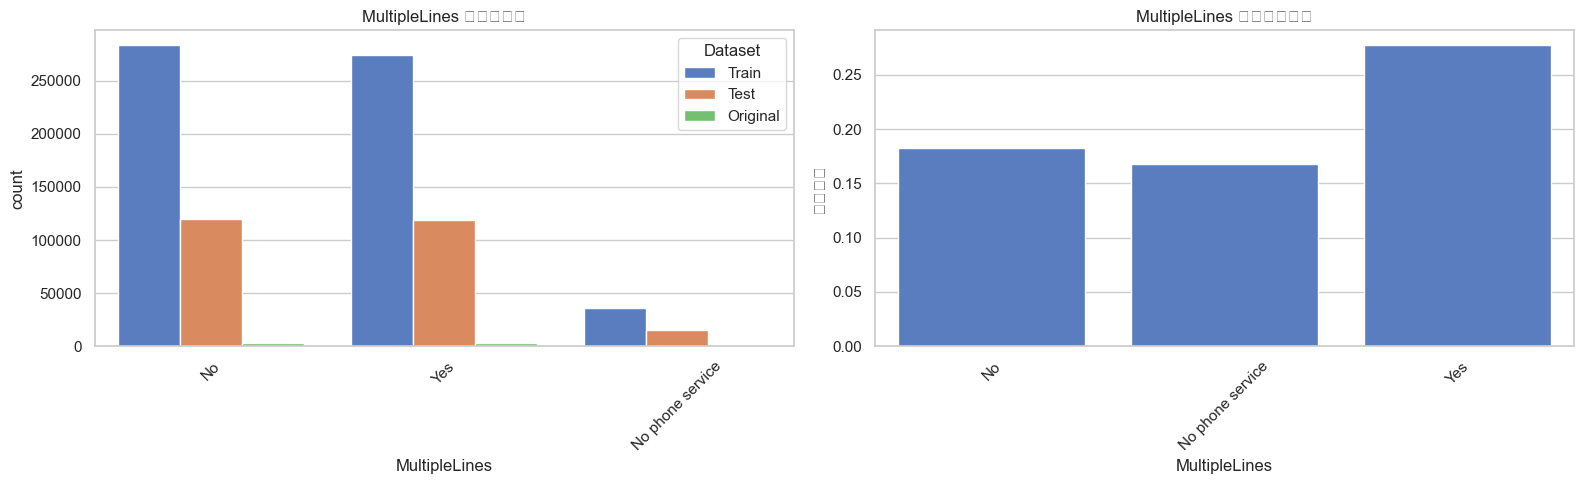

--------------------------------------------------
特征: INTERNETSERVICE
类型: 类别型
  Train -> 唯一值: 3 | 缺失值: 0 (0.00%)
  Test -> 唯一值: 3 | 缺失值: 0 (0.00%)
  Original -> 唯一值: 3 | 缺失值: 0 (0.00%)


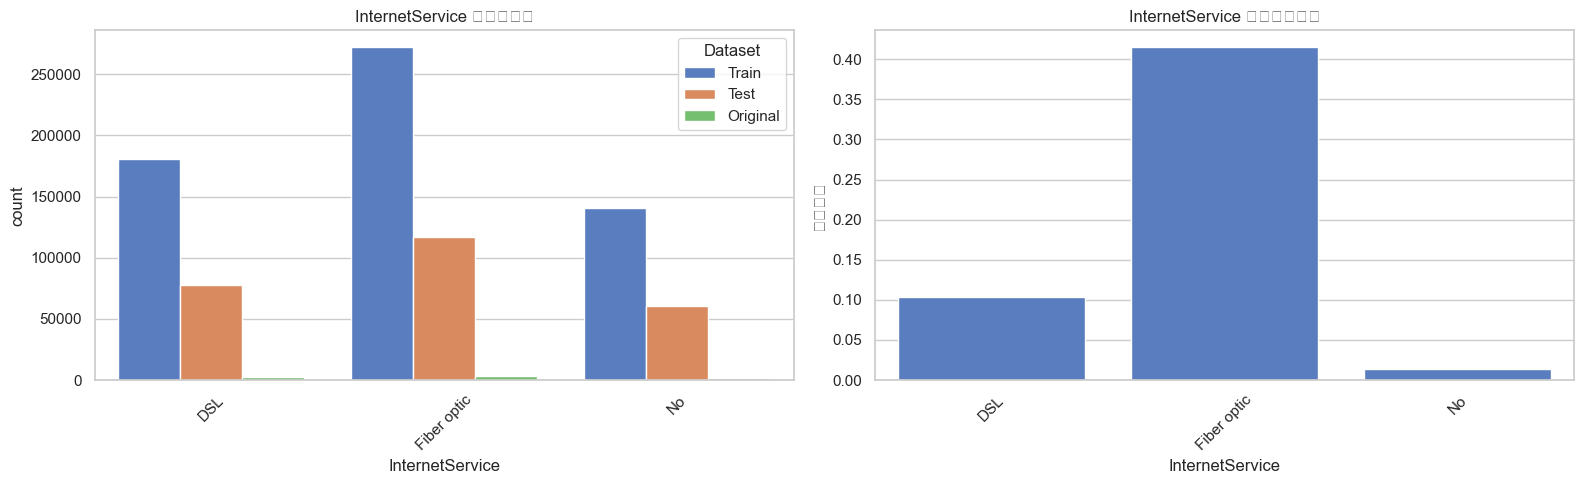

--------------------------------------------------
特征: ONLINESECURITY
类型: 类别型
  Train -> 唯一值: 3 | 缺失值: 0 (0.00%)
  Test -> 唯一值: 3 | 缺失值: 0 (0.00%)
  Original -> 唯一值: 3 | 缺失值: 0 (0.00%)


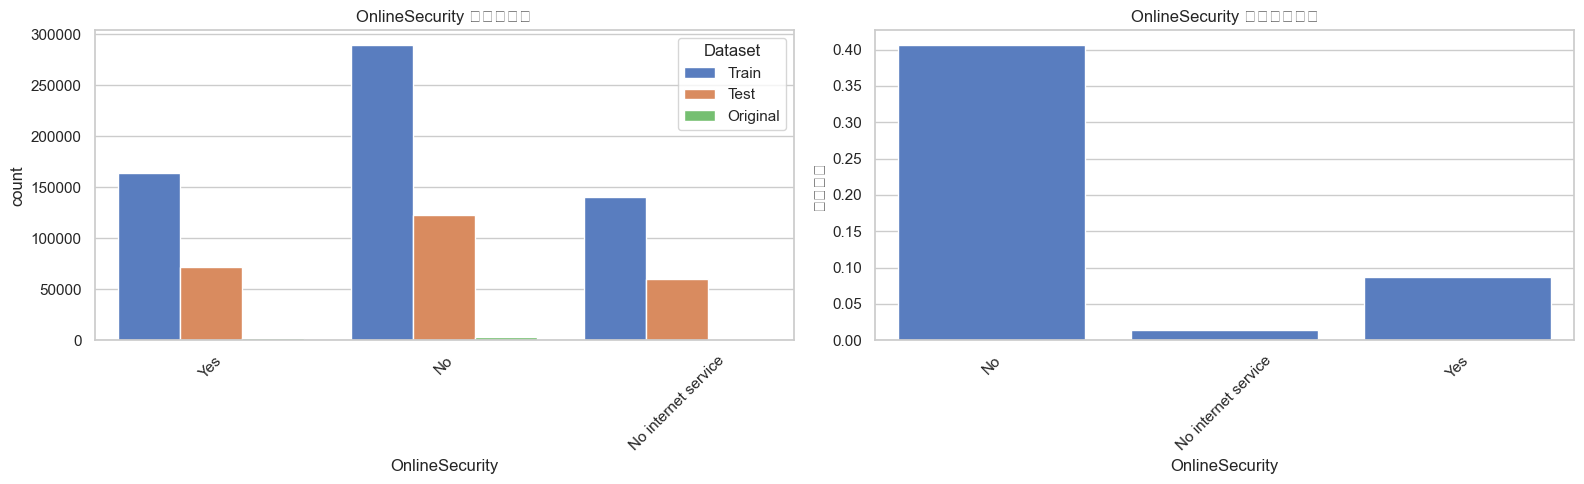

--------------------------------------------------
特征: ONLINEBACKUP
类型: 类别型
  Train -> 唯一值: 3 | 缺失值: 0 (0.00%)
  Test -> 唯一值: 3 | 缺失值: 0 (0.00%)
  Original -> 唯一值: 3 | 缺失值: 0 (0.00%)


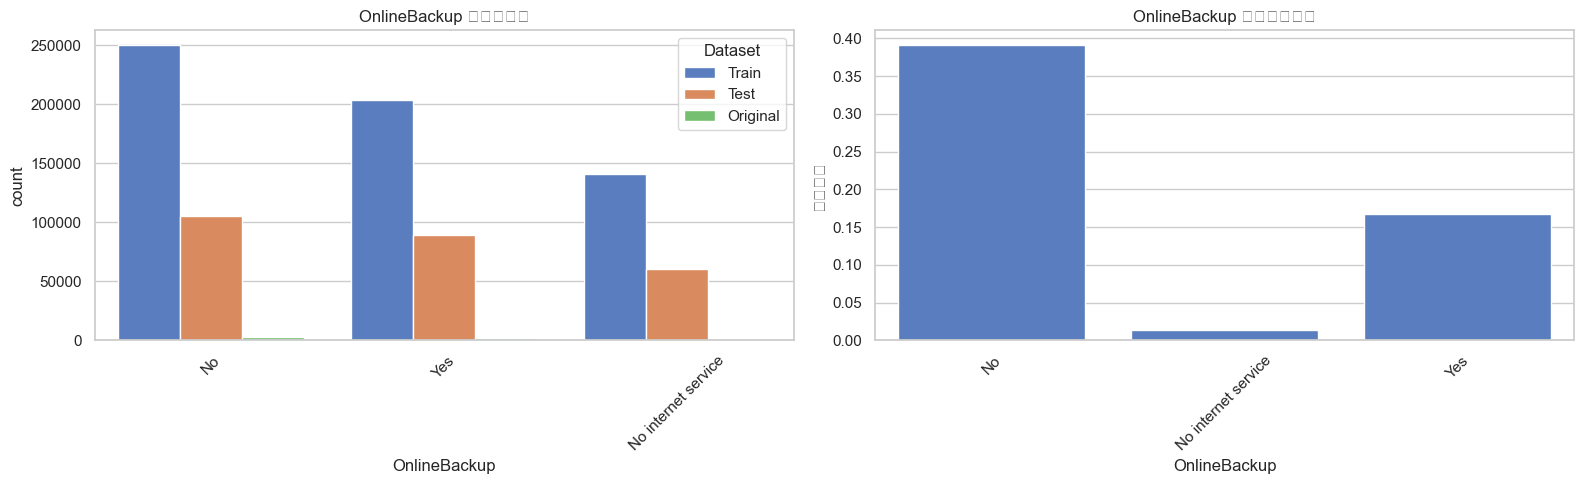

--------------------------------------------------
特征: DEVICEPROTECTION
类型: 类别型
  Train -> 唯一值: 3 | 缺失值: 0 (0.00%)
  Test -> 唯一值: 3 | 缺失值: 0 (0.00%)
  Original -> 唯一值: 3 | 缺失值: 0 (0.00%)


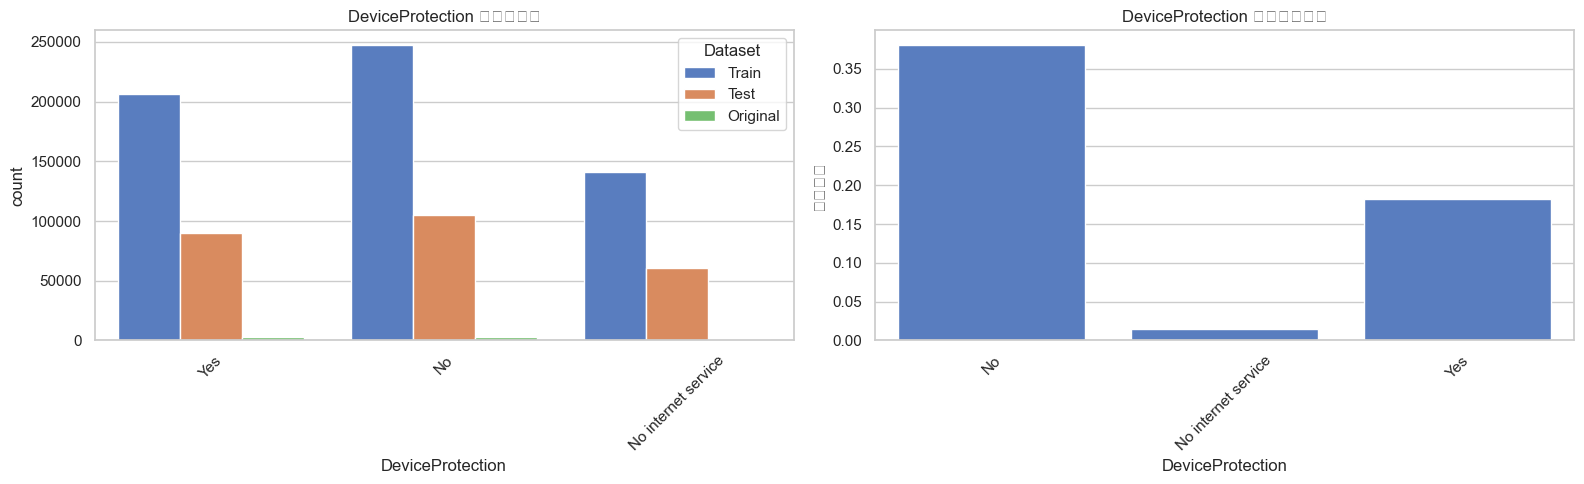

--------------------------------------------------
特征: TECHSUPPORT
类型: 类别型
  Train -> 唯一值: 3 | 缺失值: 0 (0.00%)
  Test -> 唯一值: 3 | 缺失值: 0 (0.00%)
  Original -> 唯一值: 3 | 缺失值: 0 (0.00%)


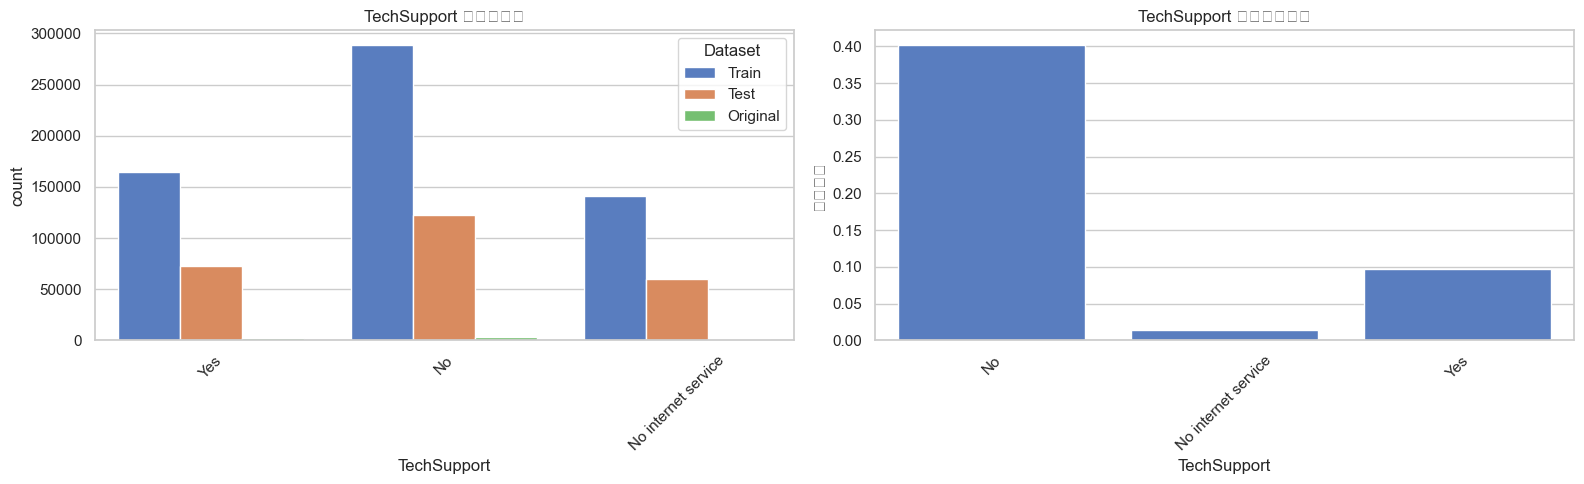

--------------------------------------------------
特征: STREAMINGTV
类型: 类别型
  Train -> 唯一值: 3 | 缺失值: 0 (0.00%)
  Test -> 唯一值: 3 | 缺失值: 0 (0.00%)
  Original -> 唯一值: 3 | 缺失值: 0 (0.00%)


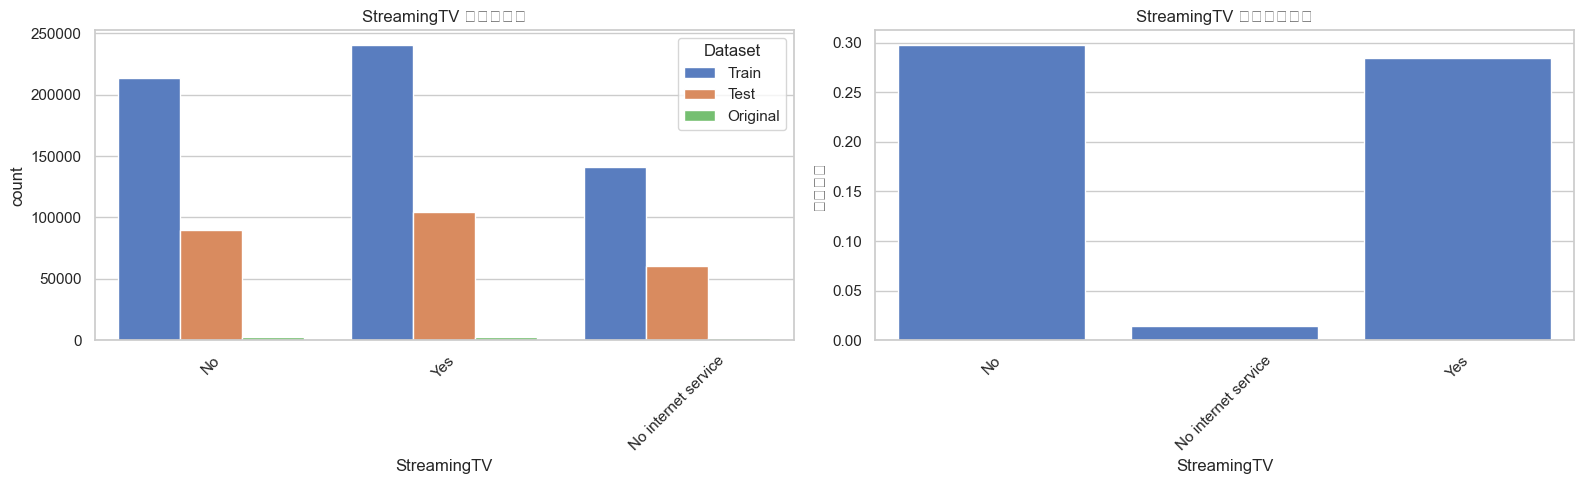

--------------------------------------------------
特征: STREAMINGMOVIES
类型: 类别型
  Train -> 唯一值: 3 | 缺失值: 0 (0.00%)
  Test -> 唯一值: 3 | 缺失值: 0 (0.00%)
  Original -> 唯一值: 3 | 缺失值: 0 (0.00%)


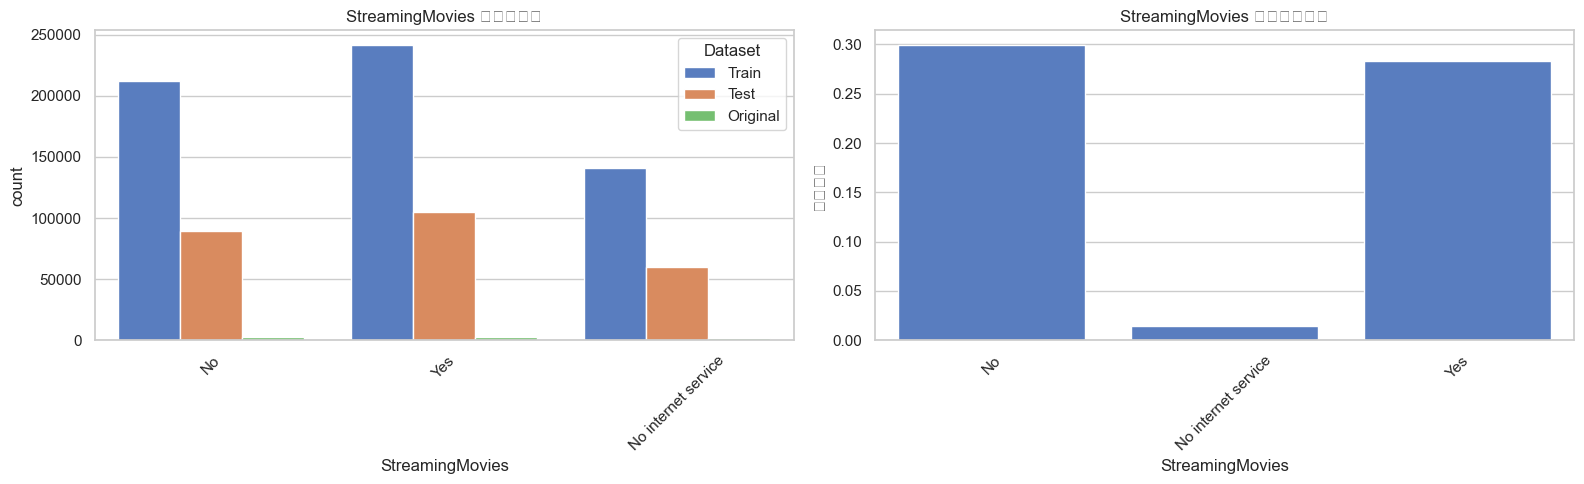

--------------------------------------------------
特征: CONTRACT
类型: 类别型
  Train -> 唯一值: 3 | 缺失值: 0 (0.00%)
  Test -> 唯一值: 3 | 缺失值: 0 (0.00%)
  Original -> 唯一值: 3 | 缺失值: 0 (0.00%)


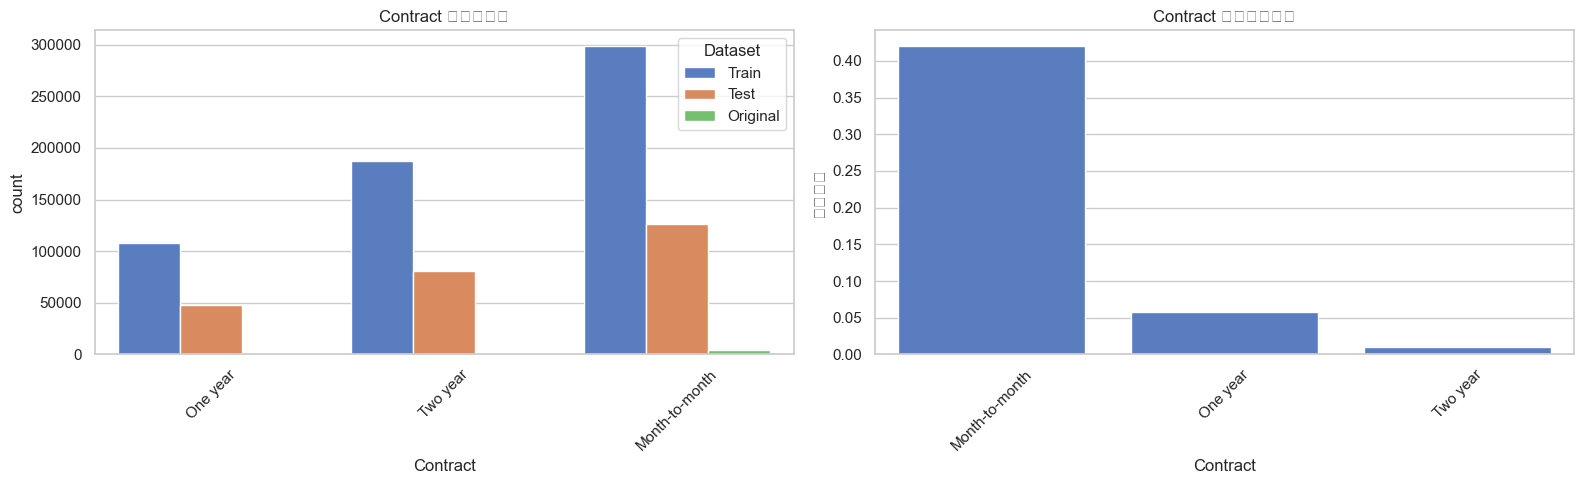

--------------------------------------------------
特征: PAPERLESSBILLING
类型: 类别型
  Train -> 唯一值: 2 | 缺失值: 0 (0.00%)
  Test -> 唯一值: 2 | 缺失值: 0 (0.00%)
  Original -> 唯一值: 2 | 缺失值: 0 (0.00%)


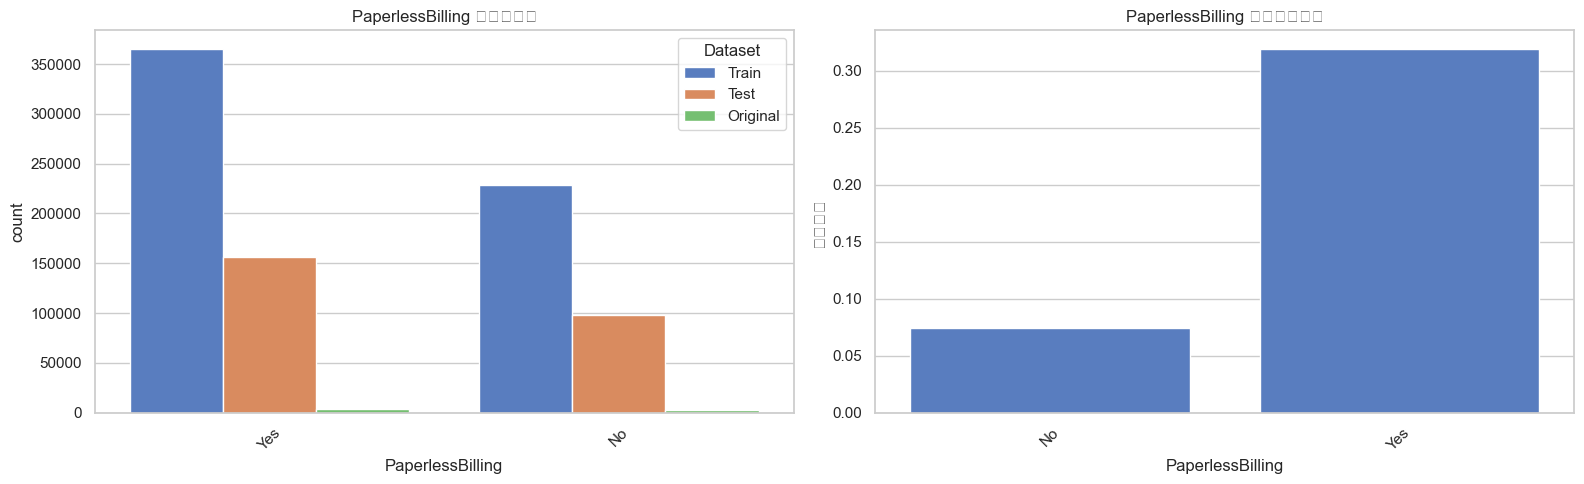

--------------------------------------------------
特征: PAYMENTMETHOD
类型: 类别型
  Train -> 唯一值: 4 | 缺失值: 0 (0.00%)
  Test -> 唯一值: 4 | 缺失值: 0 (0.00%)
  Original -> 唯一值: 4 | 缺失值: 0 (0.00%)


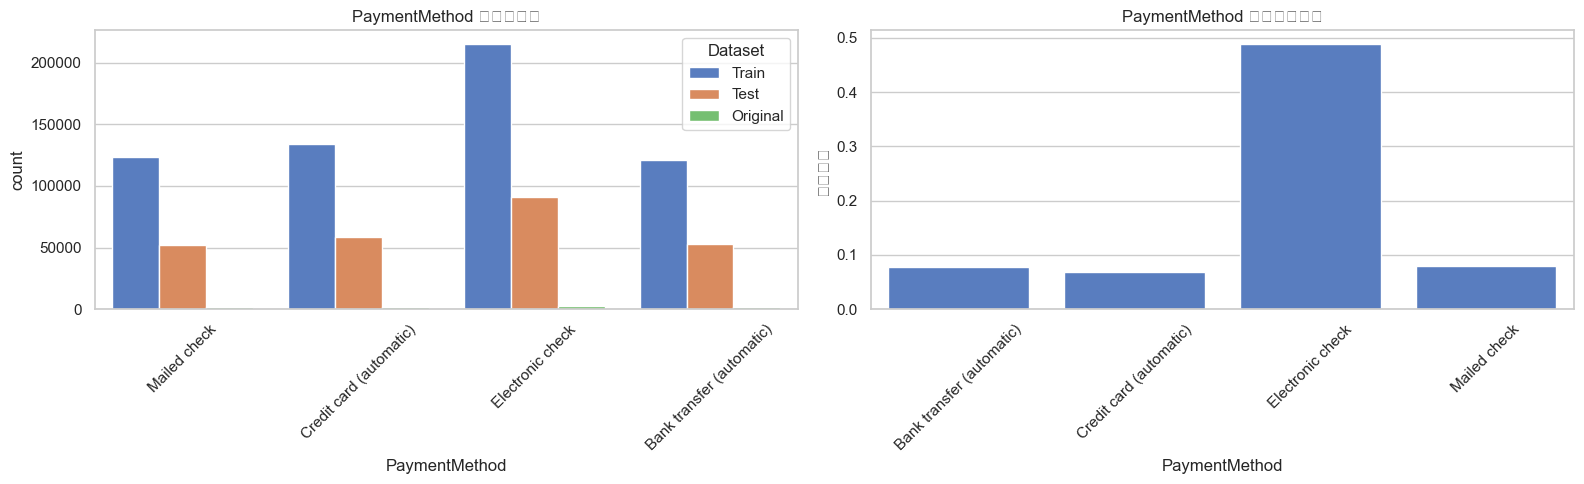

--------------------------------------------------
特征: MONTHLYCHARGES
类型: 数值型
  Train -> 唯一值: 1921 | 缺失值: 0 (0.00%)
  Test -> 唯一值: 1875 | 缺失值: 0 (0.00%)
  Original -> 唯一值: 1585 | 缺失值: 0 (0.00%)


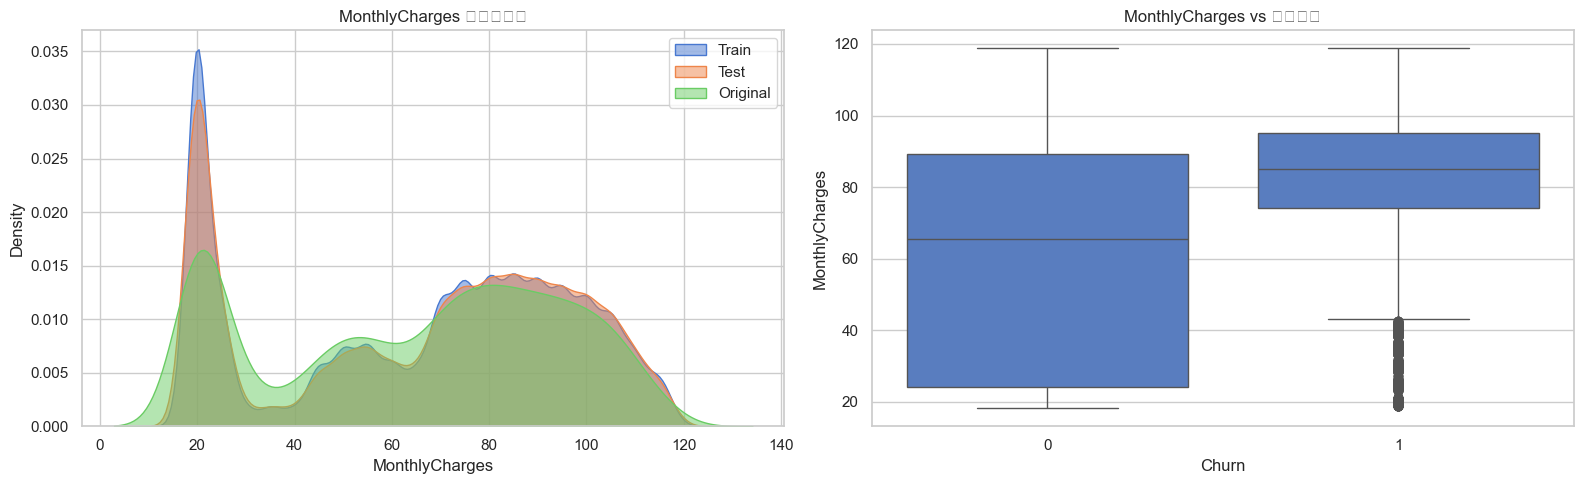

--------------------------------------------------
特征: TOTALCHARGES
类型: 数值型
  Train -> 唯一值: 31910 | 缺失值: 0 (0.00%)
  Test -> 唯一值: 24995 | 缺失值: 0 (0.00%)
  Original -> 唯一值: 6531 | 缺失值: 0 (0.00%)


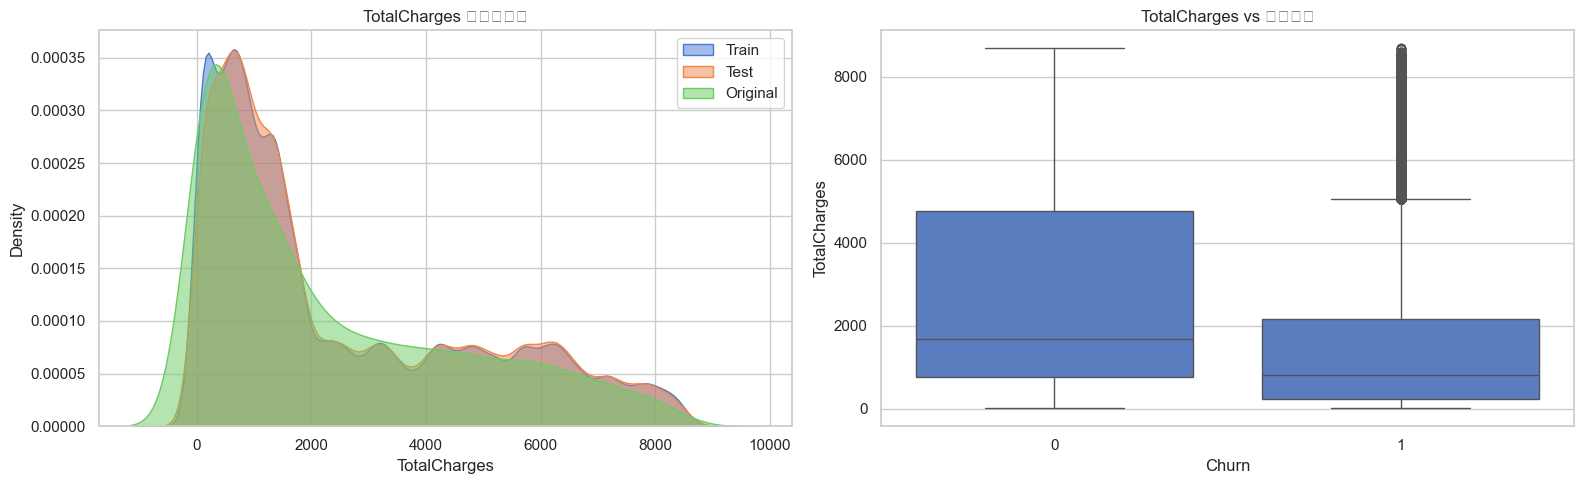

In [5]:
# ========== 数据预处理 ==========
def prep_data(train, test, orig):
    """数据清洗和预处理"""
    datasets = {'Train': train, 'Test': test, 'Original': orig}
    
    for name, df in datasets.items():
        # 1. 处理 TotalCharges 的空格问题
        if 'TotalCharges' in df.columns:
            df['TotalCharges'] = pd.to_numeric(df['TotalCharges'].replace(' ', np.nan))
            df['TotalCharges'] = df['TotalCharges'].fillna(0)  # 新用户总费用为0
        
        # 2. 将目标变量转为 0/1（仅原始数据）
        if 'Churn' in df.columns and df['Churn'].dtype == 'object':
            df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})
        
        # 3. 删除无用的ID列
        if 'id' in df.columns:
            df.drop('id', axis=1, inplace=True)
        elif 'customerID' in df.columns:
            df.drop('customerID', axis=1, inplace=True)
    
    return train, test, orig

# ========== 自动EDA函数 ==========
def auto_eda(train, test, orig, target='Churn'):
    """自动分析所有特征并生成可视化"""
    
    # 识别特征类型
    features = [col for col in train.columns if col != target]
    numeric_features = train[features].select_dtypes(include=['int64', 'float64']).columns.tolist()
    categorical_features = train[features].select_dtypes(include=['object', 'category']).columns.tolist()
    
    # 把低基数的数值特征（如 SeniorCitizen）当作类别处理
    for col in numeric_features[:]:
        if train[col].nunique() <= 5:
            numeric_features.remove(col)
            categorical_features.append(col)
    
    print("="*50)
    print("📊 EDA REPORT")
    print("="*50)
    print(f"数值特征 ({len(numeric_features)}): {numeric_features}")
    print(f"类别特征 ({len(categorical_features)}): {categorical_features}\n")
    
    # 逐个分析特征
    for col in features:
        print("-"*50)
        print(f"特征: {col.upper()}")
        
        # 打印基本信息
        col_type = '数值型' if col in numeric_features else '类别型'
        print(f"类型: {col_type}")
        
        for name, df in zip(['Train', 'Test', 'Original'], [train, test, orig]):
            if col in df.columns:
                n_unique = df[col].nunique()
                n_nan = df[col].isna().sum()
                print(f"  {name} -> 唯一值: {n_unique} | 缺失值: {n_nan} ({(n_nan/len(df))*100:.2f}%)")
        
        # 创建左右两张图
        fig, axes = plt.subplots(1, 2, figsize=(16, 5))
        
        if col_type == '数值型':
            # 左图：分布对比（训练集 vs 测试集 vs 原始数据）
            sns.kdeplot(data=train, x=col, fill=True, label='Train', ax=axes[0], alpha=0.5)
            sns.kdeplot(data=test, x=col, fill=True, label='Test', ax=axes[0], alpha=0.5)
            sns.kdeplot(data=orig, x=col, fill=True, label='Original', ax=axes[0], alpha=0.5)
            axes[0].set_title(f'{col} 的分布对比')
            axes[0].legend()
            
            # 右图：与目标变量的关系（流失 vs 未流失）
            sns.boxplot(data=train, x=target, y=col, ax=axes[1])
            axes[1].set_title(f'{col} vs 客户流失')
            
        else:
            # 左图：类别频率对比
            temp_df = pd.concat([
                train[[col]].assign(Dataset='Train'),
                test[[col]].assign(Dataset='Test'),
                orig[[col]].assign(Dataset='Original')
            ])
            sns.countplot(data=temp_df, x=col, hue='Dataset', ax=axes[0])
            axes[0].set_title(f'{col} 的频数分布')
            axes[0].tick_params(axis='x', rotation=45)
            
            # 右图：各类别的流失率
            churn_rates = train.groupby(col)[target].mean().reset_index()
            sns.barplot(data=churn_rates, x=col, y=target, ax=axes[1])
            axes[1].set_title(f'{col} 对应的流失率')
            axes[1].set_ylabel('流失概率')
            axes[1].tick_params(axis='x', rotation=45)
        
        plt.tight_layout()
        plt.show()

# ========== 执行 ==========
# 1. 读取数据（你已经有了）
train = pd.read_csv('C:/Users/GaoTing/Desktop/train.csv')
test = pd.read_csv('C:/Users/GaoTing/Desktop/test.csv')
orig = pd.read_csv('C:/Users/GaoTing/Desktop/WA_Fn-UseC_-Telco-Customer-Churn.csv')

# 2. 数据预处理
train, test, orig = prep_data(train, test, orig)

# 3. 运行自动EDA
auto_eda(train, test, orig)

# 数据预览
### 查看数据的基本信息（前五行、缺失行、重复行、数据类型、唯一值数量、列出所有列名）

In [10]:
# Shape of the dataset
display(Markdown("## <span style='color:#0f3460;font-size:20px;'>Shape of the Dataset</span>"))
display(Markdown(f"**Rows:** {train.shape[0]}  \n**Columns:** {train.shape[1]}"))

# First 5 rows
display(Markdown("### <span style='color:#0f3460; font-weight:600;'>First 5 Rows</span>"))
display(train.head())

# Missing values
display(Markdown("### <span style='color:#0f3460; font-weight:600;'>Missing Values</span>"))
display(train.isnull().sum().sort_values(ascending=False))

# Duplicate rows
display(Markdown("### <span style='color:#0f3460; font-weight:600;'>Duplicate Rows</span>"))
display(Markdown(f"**Total Duplicates:** {train.duplicated().sum()}"))

# Data types
display(Markdown("### <span style='color:#0f3460; font-weight:600;'>Data Types</span>"))
display(train.dtypes)

# Unique values per column
display(Markdown("### <span style='color:#0f3460; font-weight:600;'>Unique Values</span>"))
display(train.nunique().sort_values(ascending=False))

# Column 
display(Markdown("### <span style='color:#0f3460;font-weight:600;'>Column Names</span>"))
display(Markdown(", ".join(train.columns)))

display(Markdown("## <span style='color:#0f3460;font-weight:700; font-size:22px;'>Separate Categorical & Numerical Columns</span>"))

# detect categorical and numerical columns
categorical_cols = train.select_dtypes(include=['object']).columns.tolist()
numerical_cols = train.select_dtypes(include=['int64', 'float64']).columns.tolist()


display(Markdown("### <span style='color:#0f3460; font-weight:600;'>Categorical Columns</span>"))
display(categorical_cols)

display(Markdown("### <span style='color:#0f3460; font-weight:600;'>Numerical Columns</span>"))
display(numerical_cols)

## <span style='color:#0f3460;font-size:20px;'>Shape of the Dataset</span>

**Rows:** 594194  
**Columns:** 21

### <span style='color:#0f3460; font-weight:600;'>First 5 Rows</span>

,id,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,Male,0,Yes,Yes,29,Yes,No,DSL,Yes,No,Yes,Yes,No,No,One year,Yes,Mailed check,60.10,1653.85,No
1,1,Male,0,Yes,Yes,58,Yes,No,DSL,Yes,Yes,No,Yes,Yes,No,Two year,No,Credit card (automatic),69.50,3778.20,No
2,2,Male,0,Yes,No,58,Yes,Yes,Fiber optic,No,Yes,No,No,Yes,Yes,Month-to-month,Yes,Electronic check,100.40,5841.35,No
3,3,Female,0,No,No,1,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,69.70,70.70,Yes
4,4,Female,0,No,No,1,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.45,70.45,Yes


### <span style='color:#0f3460; font-weight:600;'>Missing Values</span>

...

## <span style='color:#0f3460;font-weight:700; font-size:22px;'>Separate Categorical & Numerical Columns</span>

### <span style='color:#0f3460; font-weight:600;'>Categorical Columns</span>

['gender',
 'Partner',
 'Dependents',
 'PhoneService',
 'MultipleLines',
 'InternetService',
 'OnlineSecurity',
 'OnlineBackup',
 'DeviceProtection',
 'TechSupport',
 'StreamingTV',
 'StreamingMovies',
 'Contract',
 'PaperlessBilling',
 'PaymentMethod',
 'Churn']

### <span style='color:#0f3460; font-weight:600;'>Numerical Columns</span>

['id', 'SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']

# 进行数据清洗与目标编码

In [11]:
target = 'Churn'
# 目标变量编码
# 将目标变量“churn”从字符串转为0/1
target_map = {'No': 0, 'Yes': 1}
#对orig数据集也做同样的处理
train[target] = train[target].map(target_map).astype(int)
orig[target]  = orig[target].map(target_map).astype(int)

# 清理TotalCharges中的异常值（转为数值、填充中位数） 
orig['TotalCharges'] = pd.to_numeric(orig['TotalCharges'], errors='coerce')
orig['TotalCharges'] = orig['TotalCharges'].fillna(orig['TotalCharges'].median())
#删除customerID 列
if 'customerID' in orig.columns:
    orig = orig.drop(columns='customerID')

# 保存id便于后续提交
train_ids = train['id'].copy()
test_ids  = test['id'].copy()

# 特征工程核心部分
#### 包含4个特征工程步骤
### 整体目标
* 从原始数据中提取更有预测能力的特征，帮助模型更好的识别流失客户
### 第一步、概率编码：捕捉稀有值的影响
### 第二步、交互特征：揭示隐藏的费用关系
### 第三步、服务特征：量化客户粘性
### 第四步、概率编码：迁移历史流失知识

In [12]:
# base columns
cats = [
    'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService',
    'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
    'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
    'Contract', 'PaperlessBilling', 'PaymentMethod',
]

nums = ['tenure', 'MonthlyCharges', 'TotalCharges']

new_nums   = []
num_as_cat = []
total_steps = 8


##第一步 ── 频率编码：将数值列转换为频率特征，捕捉熟知的稀有/常见程度 ——


display(Markdown(f"## <span style='color:#0f3460; font-weight:600;'>Step 1/{total_steps} — Frequency Encoding for Numeric Columns</span>"))

for col in nums:
    # 频率编码的主要步骤：（1）合并训练集、原始集、测试集的该列数据，（2）计算每个数值出现的频率（归一化）
    freq = pd.concat([train[col], orig[col], test[col]]) \
              .value_counts(normalize=True)

    new_col = f'freq_{col}'
    
    for df in [train, test, orig]:
        # 将原数值替换为对应的频率，缺失值填充为0
        df[new_col] = df[col].map(freq).fillna(0).astype('float32')

    new_nums.append(new_col)


##第二步 ── 算术交互特征：通过数值组合创建新特征，揭示费用模式的深层关系。——

display(Markdown(f"## <span style='color:#0f3460; font-weight:600;'>Step 2/{total_steps} — Arithmetic Interactions</span>"))

for df in [train, test, orig]:
    
    #1. 费用偏差：偏差=实际总费用-理论总费用
            #正偏差表示有额外费用，可能影响客户流失
    df['charges_deviation'] = (
        df['TotalCharges'] - df['tenure'] * df['MonthlyCharges']
    ).astype('float32')
    
   #2. 月费占比
           # 比例越高说明客户可能是新客户或近期有消费增加
    df['monthly_to_total_ratio'] = (
        df['MonthlyCharges'] / (df['TotalCharges'] + 1)
    ).astype('float32')
    
   #3. 平均月费：平均每月实际支付的费用
          # 与当前月费对比，可看出费用趋势
    df['avg_monthly_charges'] = (
        df['TotalCharges'] / (df['tenure'] + 1)
    ).astype('float32')

new_nums += [
    'charges_deviation',
    'monthly_to_total_ratio',
    'avg_monthly_charges'
]


##第三步 ── 服务特征：量化客户使用的服务数量和质量。——
display(Markdown(f"## <span style='color:#0f3460; font-weight:600;'>Step 3/{total_steps} — Service-Based Features</span>"))

service_cols = [
    'PhoneService', 'MultipleLines', 'OnlineSecurity', 'OnlineBackup',
    'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
]

for df in [train, test, orig]:
    
    #1. 服务计数：统计客户使用多少项增值服务
       #包括：电话服务、在线安全、在线备份、设备保护、技术支持、流媒体等
       #业务意义：使用服务越多，粘性越高，流失可能性越低
    
    df['service_count'] = (
        (df[service_cols] == 'Yes').sum(axis=1)
    ).astype('float32')

    #2. 是否有互联网
       # 互联网用户与仅电话用户的流失模式可能不同
    df['has_internet'] = (df['InternetService'] != 'No').astype('float32')

    #3. 是否有电话
    df['has_phone']    = (df['PhoneService'] == 'Yes').astype('float32')

new_nums += ['service_count', 'has_internet', 'has_phone']


##第四步  ── 原始数据目标概率编码：利用原始Telco数据集的知识增强特征
display(Markdown(f"## <span style='color:#0f3460; font-weight:600;'>Step 4/{total_steps} — Original Dataset Target Probability Encoding</span>"))
for col in cats + nums:
    # 在原始数据中，计算每个类别对应的流失率
    prob_map = orig.groupby(col)[target].mean()
    new_col  = f'orig_proba_{col}'

    train = train.merge(prob_map.rename(new_col), on=col, how='left')
    test  = test.merge(prob_map.rename(new_col), on=col, how='left')

    for df in [train, test]:
        # 将流失率作为新特征加入训练集和测试集
        df[new_col] = df[new_col].fillna(0.5).astype('float32')

    new_nums.append(new_col)

## <span style='color:#0f3460; font-weight:600;'>Step 1/8 — Frequency Encoding for Numeric Columns</span>

## <span style='color:#0f3460; font-weight:600;'>Step 2/8 — Arithmetic Interactions</span>

## <span style='color:#0f3460; font-weight:600;'>Step 3/8 — Service-Based Features</span>

## <span style='color:#0f3460; font-weight:600;'>Step 4/8 — Original Dataset Target Probability Encoding</span>

### 第五步、百分位排名和Z-score特征工程
* 核心思想：进行对比学习，将当前客户的TotalCharges与原始数据中已标记的客户群体进行比较，判断这个客户更像流失者还是非流失者。

In [6]:
# ── distribution features
display(Markdown(f"## <span style='color:#0f3460; font-weight:600;'>Step 5 of {total_steps} — Percentile-rank & z-score features</span>"))

# 计算values在reference分布中的百分位排名
def pctrank_against(values, reference):
    ref_sorted = np.sort(reference)
    return (np.searchsorted(ref_sorted, values) / len(ref_sorted)).astype('float32')

# 计算Z-score（标准化分数）
def zscore_against(values, reference):
    mu, sigma = np.mean(reference), np.std(reference)
    
    if sigma == 0:
        return np.zeros(len(values), dtype='float32')
    
    return ((values - mu) / sigma).astype('float32')


orig_churner_tc    = orig.loc[orig[target] == 1, 'TotalCharges'].values #流失用户的费用
orig_nonchurner_tc = orig.loc[orig[target] == 0, 'TotalCharges'].values #非流失用户的费用
orig_tc            = orig['TotalCharges'].values                        # 所有用户的费用

orig_is_mc_mean = orig.groupby('InternetService')['MonthlyCharges'].mean()# 各互联网类型的平均月费


for df in [train, test]:

    tc = df['TotalCharges'].values

    #  百分位排名特征
    #1.在非流失群体中的百分位	排名越高，越不像稳定客户
    df['pctrank_nonchurner_tc'] = pctrank_against(tc, orig_nonchurner_tc) 
    #2.在流失群体中的百分位	排名越高，越像高风险客户
    df['pctrank_churner_tc']    = pctrank_against(tc, orig_churner_tc)
    #3.在全体原始客户中的百分位	整体费用水平定位
    df['pctrank_orig_tc']       = pctrank_against(tc, orig_tc)

    # Z-score特征
    # 与非流失群体均值的标准差距离	 正值越高，越偏离稳定客户模式
    df['zscore_nonchurner_tc'] = zscore_against(tc, orig_nonchurner_tc)

    # 差距特征
    
    # 客户距离流失群体 vs 非流失群体的相对远近
      #负值：更接近非流失群体（安全）
      #正值：更接近流失群体（高风险）
    df['zscore_churn_gap_tc'] = (
        np.abs(zscore_against(tc, orig_churner_tc)) -
        np.abs(zscore_against(tc, orig_nonchurner_tc))
    ).astype('float32')

    # 在流失群体 vs 非流失群体中的百分位差异
      #负值：在非流失群体中排名更高（相对安全）
      #正值：在流失群体中排名更高（高风险）
    df['pctrank_churn_gap_tc'] = (
        pctrank_against(tc, orig_churner_tc) -
        pctrank_against(tc, orig_nonchurner_tc)
    ).astype('float32')

    # 残差特征：月费与同类互联网服务客户平均月费的差异
      #正残差：比同类用户付费更高
    df['resid_is_mc'] = (
        df['MonthlyCharges'] -
        df['InternetService'].map(orig_is_mc_mean).fillna(0)
    ).astype('float32')


    # ── 条件百分位特征：在与自己相同互联网类型的客户群体中的百分位
       # 避免不同群体间的比较偏差
    vals = np.zeros(len(df), dtype='float32')

    for cat_val in orig['InternetService'].unique():
        mask = df['InternetService'] == cat_val
        ref  = orig.loc[orig['InternetService'] == cat_val, 'TotalCharges'].values

        if len(ref) > 0 and mask.sum() > 0:
            vals[mask] = pctrank_against(
                df.loc[mask, 'TotalCharges'].values, ref
            )

    df['cond_pctrank_is_tc'] = vals


    # ── conditional percentile (contract)
    vals = np.zeros(len(df), dtype='float32')

    for cat_val in orig['Contract'].unique():
        mask = df['Contract'] == cat_val
        ref  = orig.loc[orig['Contract'] == cat_val, 'TotalCharges'].values

        if len(ref) > 0 and mask.sum() > 0:
            vals[mask] = pctrank_against(
                df.loc[mask, 'TotalCharges'].values, ref
            )

    df['cond_pctrank_c_tc'] = vals


# store new features
new_nums += [
    'pctrank_nonchurner_tc',
    'zscore_churn_gap_tc',
    'pctrank_churn_gap_tc',
    'resid_is_mc',
    'cond_pctrank_is_tc',
    'zscore_nonchurner_tc',
    'pctrank_orig_tc',
    'pctrank_churner_tc',
    'cond_pctrank_c_tc',
]

## <span style='color:#0f3460; font-weight:600;'>Step 5 of 8 — Percentile-rank & z-score features</span>

### 第六步、分位数距离特征
* 核心思想：计算客户的TotalCharges距离流失群体和非流失群体关键分位数点的距离，判断更接近哪类客户。

In [7]:
# ── quantile distance features
display(Markdown(f"## <span style='color:#0f3460; font-weight:600;'>Step 6 of {total_steps} — Quantile-distance features</span>"))

# 计算三个关键分位数：
  # q25 (25%)：下四分位数，代表"较低费用"的典型客户
  # q50 (50%)：中位数，代表"典型"客户
  # q75 (75%)：上四分位数，代表"较高费用"的典型客户
for q_label, q_val in [('q25', 0.25), ('q50', 0.50), ('q75', 0.75)]:

    ch_q = np.quantile(orig_churner_tc, q_val)
    nc_q = np.quantile(orig_nonchurner_tc, q_val)

    #生成特征
    for df in [train, test]:
        #距离特征：客户的费用距离流失/非流失群体分位点的绝对距离
            #距离流失群体中位数多远	越小越像典型流失客户
        df[f'dist_to_ch_{q_label}'] = np.abs(df['TotalCharges'] - ch_q).astype('float32')
            #距离非流失群体中位数多远	越小越像典型稳定客户
        df[f'dist_to_nc_{q_label}'] = np.abs(df['TotalCharges'] - nc_q).astype('float32')
            # 距离差距特征：到非流失群体的距离 - 到流失群体的距离
               #负数：更接近流失群体（高风险）
               #正数：更接近非流失群体（安全）
               #接近0：处于两类客户的分界线上
        df[f'qdist_gap_to_{q_label}'] = (
            df[f'dist_to_nc_{q_label}'] -
            df[f'dist_to_ch_{q_label}']
        ).astype('float32')


new_nums += [
    'qdist_gap_to_q50', 'dist_to_ch_q50', 'dist_to_nc_q50',
    'dist_to_nc_q25', 'qdist_gap_to_q25',
    'dist_to_nc_q75', 'dist_to_ch_q75', 'qdist_gap_to_q75',
]


# ── 数字/舍入特征：提取数值的数字模式特征，捕捉人类行为中的"整数偏好"或"舍入习惯"。
display(Markdown(f"## <span style='color:#0f3460; font-weight:600;'>Step 7 of {total_steps} — Digit / rounding features</span>"))

digit_features = [
    'tenure_first_digit', 'tenure_last_digit', 'tenure_mod10', 'tenure_mod12',
    'tenure_num_digits', 'tenure_is_multiple_10', 'tenure_rounded_10',
    'tenure_dev_from_round10', 'mc_first_digit', 'mc_last_digit',
    'mc_second_digit', 'mc_mod10', 'mc_mod100', 'mc_num_digits',
    'mc_is_multiple_10', 'mc_is_multiple_50', 'mc_rounded_10',
    'mc_fractional', 'mc_dev_from_round10', 'tc_first_digit', 'tc_last_digit',
    'tc_second_digit', 'tc_mod10', 'tc_mod100', 'tc_num_digits',
    'tc_is_multiple_10', 'tc_is_multiple_100', 'tc_rounded_100',
    'tc_fractional', 'tc_dev_from_round100', 'tenure_years',
    'tenure_months_in_year', 'mc_per_digit', 'tc_per_digit',
]

## <span style='color:#0f3460; font-weight:600;'>Step 6 of 8 — Quantile-distance features</span>

## <span style='color:#0f3460; font-weight:600;'>Step 7 of 8 — Digit / rounding features</span>

### 第七步、数字/舍入特征的具体实现
* 整十/整百偏好	客户喜欢简单整数套餐
* 小数部分	心理定价（99结尾）vs 精确计算
* 数字位数	费用量级

In [8]:
for df in [train, test]:

    #  数字提取特征
    t_str = df['tenure'].astype(str)

    df['tenure_first_digit']      = t_str.str[0].astype(int)
    df['tenure_last_digit']       = t_str.str[-1].astype(int)
    df['tenure_second_digit']     = t_str.apply(lambda x: int(x[1]) if len(x) > 1 else 0)
    # mod运算特征：mod10=0(整十月份10，20，30....)
    df['tenure_mod10']            = df['tenure'] % 10
    df['tenure_mod12']            = df['tenure'] % 12
    # 数字属性特征
    df['tenure_num_digits']       = t_str.str.len()
    df['tenure_is_multiple_10']   = (df['tenure'] % 10 == 0).astype('float32')#是否为10的倍数
    #四舍五入
    df['tenure_rounded_10']       = np.round(df['tenure'] / 10) * 10#四舍五入到10
    df['tenure_dev_from_round10'] = abs(df['tenure'] - df['tenure_rounded_10'])#偏差值
    #年月转换
    df['tenure_years']            = df['tenure'] // 12
    df['tenure_months_in_year']   = df['tenure'] % 12

    # 月费特征
    #1.字符串处理：移除小数点便于提取数字
    mc_str = df['MonthlyCharges'].astype(str).str.replace('.', '', regex=False)
    #2.数字提取
    df['mc_first_digit']      = mc_str.str[0].astype(int)
    df['mc_last_digit']       = mc_str.str[-1].astype(int)
    df['mc_second_digit']     = mc_str.apply(lambda x: int(x[1]) if len(x) > 1 else 0)
    #整数部分
    df['mc_mod10']            = np.floor(df['MonthlyCharges']) % 10
    df['mc_mod100']           = np.floor(df['MonthlyCharges']) % 100
    df['mc_num_digits']       = np.floor(df['MonthlyCharges']).astype(int).astype(str).str.len()
    #倍数判断
    df['mc_is_multiple_10']   = (np.floor(df['MonthlyCharges']) % 10 == 0).astype('float32')
    df['mc_is_multiple_50']   = (np.floor(df['MonthlyCharges']) % 50 == 0).astype('float32')
    df['mc_rounded_10']       = np.round(df['MonthlyCharges'] / 10) * 10
    #小数部分特征
    df['mc_fractional']       = df['MonthlyCharges'] - np.floor(df['MonthlyCharges'])
    df['mc_dev_from_round10'] = abs(df['MonthlyCharges'] - df['mc_rounded_10'])
    df['mc_per_digit']        = df['MonthlyCharges'] / (df['mc_num_digits'] + 0.001)

    # 总费用特征
    tc_str = df['TotalCharges'].astype(str).str.replace('.', '', regex=False)

    df['tc_first_digit']       = tc_str.str[0].astype(int)
    df['tc_last_digit']        = tc_str.str[-1].astype(int)
    df['tc_second_digit']      = tc_str.apply(lambda x: int(x[1]) if len(x) > 1 else 0)
    df['tc_mod10']             = np.floor(df['TotalCharges']) % 10
    df['tc_mod100']            = np.floor(df['TotalCharges']) % 100
    df['tc_num_digits']        = np.floor(df['TotalCharges']).astype(int).astype(str).str.len()
    df['tc_is_multiple_10']    = (np.floor(df['TotalCharges']) % 10 == 0).astype('float32')
    df['tc_is_multiple_100']   = (np.floor(df['TotalCharges']) % 100 == 0).astype('float32')
    df['tc_rounded_100']       = np.round(df['TotalCharges'] / 100) * 100
    df['tc_fractional']        = df['TotalCharges'] - np.floor(df['TotalCharges'])
    df['tc_dev_from_round100'] = abs(df['TotalCharges'] - df['tc_rounded_100'])
    df['tc_per_digit']         = df['TotalCharges'] / (df['tc_num_digits'] + 0.001)

new_nums += digit_features


### 第八步、N-gram类别特征工程
* 将多个类别特征组合成新的复合类别，捕捉特征之间的交互效应。类似于NLP中的N-gram概念，但应用于表格数据的类别特征。


In [9]:
# ──categorical features
display(Markdown(f"## <span style='color:#0f3460; font-weight:600;'>Step 8 of {total_steps} — N-gram categorical features</span>"))
bigram_cols  = []
trigram_cols = []

#1. 数据准备（选择这些特征的原因：都与客户行为和风险高度相关、组合后能产生更强的预测信号）
top_cats_for_ngram = [
    'Contract', 'InternetService', 'PaymentMethod',
    'OnlineSecurity', 'TechSupport', 'PaperlessBilling',
]
#2. 创建Bi-gram特征（二阶组合）生成所有不重复的组合：C（6，2）=15
for c1, c2 in combinations(top_cats_for_ngram, 2):
    col_name = f"bg_{c1}_{c2}"

    for df in [train, test]:
        df[col_name] = (df[c1].astype(str) + "_" + df[c2].astype(str)).astype('category')

    bigram_cols.append(col_name)
    
# 创建Tri-gram特征（三阶组合）
top4 = top_cats_for_ngram[:4] #取特征的前四个

for c1, c2, c3 in combinations(top4, 3):
    col_name = f"tg_{c1}_{c2}_{c3}"

    for df in [train, test]:
        df[col_name] = (
            df[c1].astype(str) + "_" +
            df[c2].astype(str) + "_" +
            df[c3].astype(str)
        ).astype('category')

    trigram_cols.append(col_name)

display(Markdown(f"→ **Bi-grams:** <span style='color:#0f3460; font-weight:600;'>{len(bigram_cols)}</span>"))
display(Markdown(f"→ **Tri-grams:** <span style='color:#0f3460; font-weight:600;'>{len(trigram_cols)}</span>"))

## <span style='color:#0f3460; font-weight:600;'>Step 8 of 8 — N-gram categorical features</span>

→ **Bi-grams:** <span style='color:#0f3460; font-weight:600;'>15</span>

→ **Tri-grams:** <span style='color:#0f3460; font-weight:600;'>4</span>

### 特征工程收尾工作
* 创建数值特征的类别版本
* 汇总所有特征
* 统计特征数量


In [10]:
# ── 数值特征转类别：
for col in nums:
    new_col = f'cat_{col}'
    num_as_cat.append(new_col)

    for df in [train, test]:
        df[new_col] = df[col].astype(str).astype('category')


# 特征分组汇总
features          = nums + cats + new_nums + num_as_cat + bigram_cols + trigram_cols
# 目标编码列定义
te_columns        = num_as_cat + cats
te_ngram_columns  = bigram_cols + trigram_cols
to_remove         = num_as_cat + cats + bigram_cols + trigram_cols


display(Markdown("## <span style='color:#0f3460; font-weight:600;'>Feature Summary</span>"))
display(Markdown(f"**Total features:** {len(features)}"))
display(Markdown(f"**Base numerical:** {len(nums)}"))
display(Markdown(f"**Base categorical:** {len(cats)}"))
display(Markdown(f"**Engineered numerical:** {len(new_nums)}"))
display(Markdown(f"**Num-as-Cat:** {len(num_as_cat)}"))
display(Markdown(f"**Bi-gram:** {len(bigram_cols)}"))
display(Markdown(f"**Tri-gram:** {len(trigram_cols)}"))

## <span style='color:#0f3460; font-weight:600;'>Feature Summary</span>

**Total features:** 120

**Base numerical:** 3

**Base categorical:** 16

**Engineered numerical:** 79

**Num-as-Cat:** 3

**Bi-gram:** 15

**Tri-gram:** 4

# 嵌套交叉验证和XGBoost模型的参数配置

In [11]:
target       = 'Churn'# 目标变量名
n_folds      = 20 # 外层交叉验证折数
inner_folds  = 5# 内层交叉验证折数（用于目标编码）
random_seed  = 42# 随机种子（保证可重复性）

#N-gram特征列定义
top_cats_for_ngram = [
    'Contract', 'InternetService', 'PaymentMethod',
    'OnlineSecurity', 'TechSupport', 'PaperlessBilling',
]

# XGBoost超参数详解
xgb_params = {
    'n_estimators':          35000,
    'learning_rate':         0.0058,
    'max_depth':             5,
    'max_leaves':            0,
    'subsample':             0.80,
    'colsample_bytree':      0.30,
    'colsample_bylevel':     0.85,
    'colsample_bynode':      0.90,
    'min_child_weight':      7,
    'reg_alpha':             3.60,
    'reg_lambda':            1.35,
    'gamma':                 0.82,
    'max_delta_step':        1,
    'scale_pos_weight':      1.0,
    'grow_policy':           'depthwise',
    'random_state':          random_seed,
    'early_stopping_rounds': 600,
    'objective':             'binary:logistic',
    'eval_metric':           'auc',
    'enable_categorical':    True,
    'device':                'cuda',
    'verbosity':             0,
}

In [12]:
display(Markdown(
    f"## <span style='color:#0f3460; font-weight:600;'>─ Training ({n_folds}-Fold Stratified CV)</span>"
))

# 初始化设置
np.random.seed(random_seed)
skf_outer = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=random_seed)
skf_inner = StratifiedKFold(n_splits=inner_folds, shuffle=True, random_state=random_seed)

#StratifiedKFold（分层K折）
##分层：保持每折中正负样本比例与整体一致
##洗牌：随机打乱数据顺序
##固定种子：保证可重复性
oof                 = np.zeros(len(train))# Out-Of-Fold预测（用于最终评估）
pred                = np.zeros(len(test)) # 测试集预测（累积）
fold_scores         = [] # 每折AUC分数
feature_importances = []# 每折特征重要性
fold_evals          = []# 每折训练历史

t0 = time.time()

#外层循环
for i, (train_idx, val_idx) in enumerate(skf_outer.split(train, train[target])):
    fold_start = time.time()
    fold_num   = i + 1
    display(Markdown(
        f"### <span style='color:#0f3460; font-weight:600;'>Fold {fold_num}/{n_folds}</span>  "
        f"(train={len(train_idx):,}  val={len(val_idx):,})"
    ))

    #数据划分
    x_tr  = train.loc[train_idx, features + [target]].reset_index(drop=True).copy()
    y_tr  = train.loc[train_idx, target].values
    x_val = train.loc[val_idx, features].reset_index(drop=True).copy()
    y_val = train.loc[val_idx, target].values
    x_te  = test[features].reset_index(drop=True).copy()

    # ── 内层目标编码
    '''
    流程：
    内层5折循环
    每折中，用内层训练集计算统计量（std, min, max）
    将统计量赋值给内层验证集
    最终x_tr获得所有样本的统计量
    '''
    for j, (in_tr, in_va) in enumerate(skf_inner.split(x_tr, y_tr)):
        x_tr2 = x_tr.loc[in_tr, features + [target]].copy()
        x_va2 = x_tr.loc[in_va, features].copy()
        for col in te_columns:
            tmp = x_tr2.groupby(col, observed=False)[target].agg(['std', 'min', 'max'])
            tmp.columns = [f"te1_{col}_{s}" for s in ['std', 'min', 'max']]
            x_va2 = x_va2.merge(tmp, on=col, how="left")
            for c in tmp.columns:
                x_tr.loc[in_va, c] = x_va2[c].values.astype("float32")

    # ── 全折统计（用于验证集和测试集）
    for col in te_columns:
        tmp = x_tr.groupby(col, observed=False)[target].agg(['std', 'min', 'max'])
        tmp.columns = [f"te1_{col}_{s}" for s in ['std', 'min', 'max']]
        tmp = tmp.astype("float32")
        x_val = x_val.merge(tmp, on=col, how="left")
        x_te  = x_te.merge(tmp, on=col, how="left")
        for c in tmp.columns:
            for df in [x_tr, x_val, x_te]:
                df[c] = df[c].fillna(0)

    # ──  N-gram特征编码
    for j, (in_tr, in_va) in enumerate(skf_inner.split(x_tr, y_tr)):
        x_tr2 = x_tr.loc[in_tr].copy()
        x_va2 = x_tr.loc[in_va].copy()
        for col in te_ngram_columns:
            ng_te   = x_tr2.groupby(col, observed=False)[target].mean()
            ng_name = f"te_ng_{col}"
            mapped  = x_va2[col].astype(str).map(ng_te)
            x_tr.loc[in_va, ng_name] = (
                pd.to_numeric(mapped, errors='coerce').fillna(0.5).astype('float32').values
            )

    # ── Full-fold TE: N-grams on val/test
    for col in te_ngram_columns:
        ng_te   = x_tr.groupby(col, observed=False)[target].mean()
        ng_name = f"te_ng_{col}"
        x_val[ng_name] = pd.to_numeric(
            x_val[col].astype(str).map(ng_te), errors='coerce'
        ).fillna(0.5).astype('float32')
        x_te[ng_name] = pd.to_numeric(
            x_te[col].astype(str).map(ng_te), errors='coerce'
        ).fillna(0.5).astype('float32')
        if ng_name in x_tr.columns:
            x_tr[ng_name] = pd.to_numeric(
                x_tr[ng_name], errors='coerce'
            ).fillna(0.5).astype('float32')
        else:
            x_tr[ng_name] = 0.5

    # ── sklearn TargetEncoder (mean)
    te_mean_cols = [f'te_{col}' for col in te_columns]
    te = TargetEncoder(
        cv=inner_folds, shuffle=True, smooth='auto',
        target_type='binary', random_state=random_seed
    )
    x_tr[te_mean_cols]  = te.fit_transform(x_tr[te_columns], y_tr)
    x_val[te_mean_cols] = te.transform(x_val[te_columns])
    x_te[te_mean_cols]  = te.transform(x_te[te_columns])

    #数据准备与清理
    # ── Drop raw categoricals 
    for df in [x_tr, x_val, x_te]:
        for c in cats + num_as_cat:
            if c in df.columns:
                df[c] = df[c].astype(str).astype("category")
        df.drop(columns=[c for c in to_remove if c in df.columns],
                inplace=True, errors='ignore')
    x_tr.drop(columns=[target], inplace=True, errors='ignore')
    cols_xgb = x_tr.columns

    if fold_num == 1:
        print("Features per model", len(cols_xgb))

    # ── Fit XGBoost 
    model = XGBClassifier(**xgb_params)

    if fold_num == 1:
        model.fit(
            x_tr, y_tr,
            eval_set=[(x_tr, y_tr), (x_val, y_val)],
            verbose=500,
        )
        fold_evals.append(model.evals_result())
    else:
        model.fit(x_tr, y_tr, eval_set=[(x_val, y_val)], verbose=500)

    # ── Predictions
    fold_pred      = model.predict_proba(x_val)[:, 1]
    oof[val_idx]   = fold_pred
    fold_auc       = roc_auc_score(y_val, fold_pred)
    fold_scores.append(fold_auc)

    pred += model.predict_proba(x_te[cols_xgb])[:, 1] / n_folds
    feature_importances.append(model.feature_importances_)

    elapsed = time.time() - fold_start
    display(Markdown(f"""
<span style="font-size:15px;">
<span style="color:#0f3460; font-weight:bold;">│ AUC =</span> 
<span style="color:black; font-weight:bold;">{fold_auc:.5f}</span>  

<span style="color:#0f3460; font-weight:bold;">(Time):</span> 
<span style="color:black; font-weight:bold;">{elapsed/60:.1f} min</span>  

<span style="color:#0f3460; font-weight:bold;">└{'─'*50}┘</span>
</span>
"""))

    del x_tr, x_val, x_te, y_tr, y_val, model
    gc.collect()

total_time = (time.time() - t0) / 60
#divider()
display(Markdown(
    f"## <span style='color:#0f3460; font-weight:600;'>Training complete in {total_time:.1f} min</span>"
))

## <span style='color:#0f3460; font-weight:600;'>─ Training (20-Fold Stratified CV)</span>

### <span style='color:#0f3460; font-weight:600;'>Fold 1/20</span>  (train=564,484  val=29,710)

Features per model 177
[0]	validation_0-auc:0.87111	validation_1-auc:0.87236
[500]	validation_0-auc:0.91502	validation_1-auc:0.91558
[1000]	validation_0-auc:0.91739	validation_1-auc:0.91762
[1500]	validation_0-auc:0.91879	validation_1-auc:0.91860
[2000]	validation_0-auc:0.91966	validation_1-auc:0.91905
[2500]	validation_0-auc:0.92033	validation_1-auc:0.91931
[3000]	validation_0-auc:0.92091	validation_1-auc:0.91951
[3500]	validation_0-auc:0.92143	validation_1-auc:0.91964
[4000]	validation_0-auc:0.92192	validation_1-auc:0.91976
[4500]	validation_0-auc:0.92238	validation_1-auc:0.91987
[5000]	validation_0-auc:0.92283	validation_1-auc:0.91996
[5500]	validation_0-auc:0.92325	validation_1-auc:0.92004
[6000]	validation_0-auc:0.92366	validation_1-auc:0.92011
[6500]	validation_0-auc:0.92405	validation_1-auc:0.92017
[7000]	validation_0-auc:0.92443	validation_1-auc:0.92023
[7500]	validation_0-auc:0.92480	validation_1-auc:0.92026
[8000]	validation_0-auc:0.92516	validation_1-auc:0.92032
[8500]	valid


<span style="font-size:15px;">
<span style="color:#0f3460; font-weight:bold;">│ AUC =</span> 
<span style="color:black; font-weight:bold;">0.92055</span>  

<span style="color:#0f3460; font-weight:bold;">(Time):</span> 
<span style="color:black; font-weight:bold;">5.5 min</span>  

<span style="color:#0f3460; font-weight:bold;">└──────────────────────────────────────────────────┘</span>
</span>


### <span style='color:#0f3460; font-weight:600;'>Fold 2/20</span>  (train=564,484  val=29,710)

...


<span style="font-size:15px;">
<span style="color:#0f3460; font-weight:bold;">│ AUC =</span> 
<span style="color:black; font-weight:bold;">0.91833</span>  

<span style="color:#0f3460; font-weight:bold;">(Time):</span> 
<span style="color:black; font-weight:bold;">3.9 min</span>  

<span style="color:#0f3460; font-weight:bold;">└──────────────────────────────────────────────────┘</span>
</span>


### <span style='color:#0f3460; font-weight:600;'>Fold 20/20</span>  (train=564,485  val=29,709)

[0]	validation_0-auc:0.86937
[500]	validation_0-auc:0.91031
[1000]	validation_0-auc:0.91257
[1500]	validation_0-auc:0.91366
[2000]	validation_0-auc:0.91416
[2500]	validation_0-auc:0.91446
[3000]	validation_0-auc:0.91469
[3500]	validation_0-auc:0.91485
[4000]	validation_0-auc:0.91497
[4500]	validation_0-auc:0.91507
[5000]	validation_0-auc:0.91516
[5500]	validation_0-auc:0.91523
[6000]	validation_0-auc:0.91528
[6500]	validation_0-auc:0.91533
[7000]	validation_0-auc:0.91535
[7500]	validation_0-auc:0.91538
[8000]	validation_0-auc:0.91541
[8500]	validation_0-auc:0.91544
[9000]	validation_0-auc:0.91546
[9500]	validation_0-auc:0.91547
[10000]	validation_0-auc:0.91548
[10500]	validation_0-auc:0.91550
[11000]	validation_0-auc:0.91551
[11500]	validation_0-auc:0.91551
[12000]	validation_0-auc:0.91552
[12500]	validation_0-auc:0.91552
[13000]	validation_0-auc:0.91553
[13500]	validation_0-auc:0.91553
[13556]	validation_0-auc:0.91553



<span style="font-size:15px;">
<span style="color:#0f3460; font-weight:bold;">│ AUC =</span> 
<span style="color:black; font-weight:bold;">0.91554</span>  

<span style="color:#0f3460; font-weight:bold;">(Time):</span> 
<span style="color:black; font-weight:bold;">4.4 min</span>  

<span style="color:#0f3460; font-weight:bold;">└──────────────────────────────────────────────────┘</span>
</span>


## <span style='color:#0f3460; font-weight:600;'>Training complete in 84.2 min</span>

# 评估

In [13]:
overall_auc = roc_auc_score(train[target], oof)
mean_auc    = np.mean(fold_scores)
std_auc     = np.std(fold_scores)

best_fold  = np.argmax(fold_scores) + 1
worst_fold = np.argmin(fold_scores) + 1

precision, recall, _ = precision_recall_curve(train[target], oof)
ap_score = average_precision_score(train[target], oof)

display(Markdown(f"""
<span style="font-size:16px;">
<span style="color:#0f3460; font-weight:bold;">Overall CV AUC:</span> <span style="color:black; font-weight:bold;">{overall_auc:.5f}</span>  <br>
<span style="color:#0f3460; font-weight:bold;">Mean Fold AUC:</span> <span style="color:black; font-weight:bold;">{mean_auc:.5f} ± {std_auc:.5f}</span>  <br>
<span style="color:#0f3460; font-weight:bold;">Best Fold AUC:</span> <span style="color:black; font-weight:bold;">{np.max(fold_scores):.5f}  (Fold {best_fold})</span>  <br>
<span style="color:#0f3460; font-weight:bold;">Worst Fold AUC:</span> <span style="color:black; font-weight:bold;">{np.min(fold_scores):.5f}  (Fold {worst_fold})</span>  <br>
<span style="color:#0f3460; font-weight:bold;">Average Precision (AP) Score:</span> <span style="color:black; font-weight:bold;">{ap_score:.5f}</span>  
"""))


<span style="font-size:16px;">
<span style="color:#0f3460; font-weight:bold;">Overall CV AUC:</span> <span style="color:black; font-weight:bold;">0.91924</span>  <br>
<span style="color:#0f3460; font-weight:bold;">Mean Fold AUC:</span> <span style="color:black; font-weight:bold;">0.91925 ± 0.00171</span>  <br>
<span style="color:#0f3460; font-weight:bold;">Best Fold AUC:</span> <span style="color:black; font-weight:bold;">0.92310  (Fold 5)</span>  <br>
<span style="color:#0f3460; font-weight:bold;">Worst Fold AUC:</span> <span style="color:black; font-weight:bold;">0.91554  (Fold 20)</span>  <br>
<span style="color:#0f3460; font-weight:bold;">Average Precision (AP) Score:</span> <span style="color:black; font-weight:bold;">0.76115</span>  


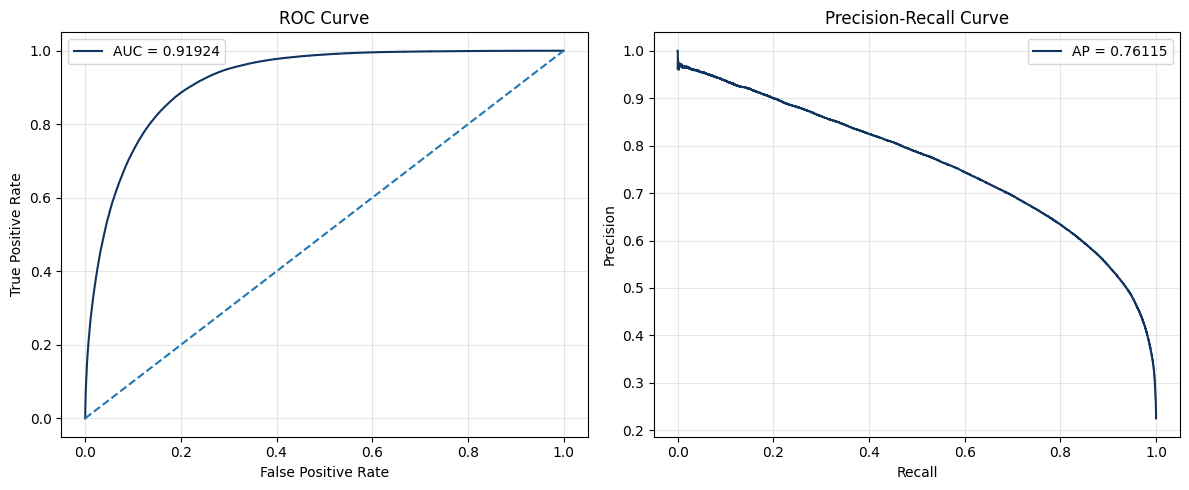

In [14]:
fpr, tpr, _ = roc_curve(train[target], oof)
roc_auc_val = auc(fpr, tpr)

precision, recall, _ = precision_recall_curve(train[target], oof)


fig, axes = plt.subplots(1, 2, figsize=(12,5))

# ROC Curve 
axes[0].plot(fpr, tpr, color="#0f3460", label=f"AUC = {roc_auc_val:.5f}")
axes[0].plot([0,1], [0,1], linestyle="--")
axes[0].set_title("ROC Curve")
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].legend()
axes[0].grid(alpha=0.3)

# Precision-Recall Curve 
axes[1].plot(recall, precision, color="#0f3460", label=f"AP = {ap_score:.5f}")
axes[1].set_title("Precision-Recall Curve")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

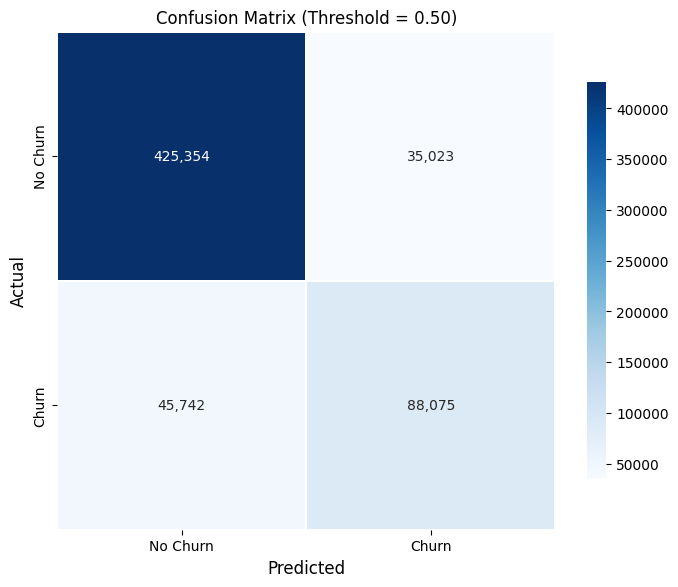

In [15]:
y_pred_binary = (oof >= 0.5).astype(int)

cm = confusion_matrix(train[target], y_pred_binary)

fig, ax = plt.subplots(figsize=(7, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt=',d',
    cmap='Blues',
    linewidths=1.2,
    linecolor='white',
    square=True,
    cbar_kws={'shrink': 0.75},
    xticklabels=['No Churn', 'Churn'],
    yticklabels=['No Churn', 'Churn'],
    ax=ax
)

ax.set_xlabel('Predicted', fontsize=12)
ax.set_ylabel('Actual', fontsize=12)
ax.set_title('Confusion Matrix (Threshold = 0.50)')

plt.tight_layout()
plt.show()

# 总结数据

In [16]:
# ── Model Evaluation Metrics 
display(Markdown("## <span style='color:#0f3460; font-weight:600;'>Model Evaluation Metrics</span>"))

# AUC & PR-AUC metrics
display(Markdown(f"- **Overall CV AUC:** <span style='color:#0f3460; font-weight:500;'>{overall_auc:.5f}</span>"))
display(Markdown(f"- **Mean ± Std Fold AUC:** <span style='color:#0f3460; font-weight:500;'>{mean_auc:.5f} ± {std_auc:.5f}</span>"))
display(Markdown(f"- **Avg Precision (PR-AUC):** <span style='color:#0f3460; font-weight:500;'>{ap_score:.5f}</span>"))

# predictions info
display(Markdown(f"- **Mean P(Churn) — test:** <span style='color:#0f3460; font-weight:500;'>{np.mean(pred):.5f}</span>"))
display(Markdown(f"- **Predicted churn rate (test):** <span style='color:#0f3460; font-weight:500;'>{(pred >= 0.5).mean()*100:.2f}%</span>"))
display(Markdown(f"- **Mean P(Churn) — OOF:** <span style='color:#0f3460; font-weight:500;'>{np.mean(oof):.5f}</span>"))
display(Markdown(f"- **Actual churn rate (train):** <span style='color:#0f3460; font-weight:500;'>{train[target].mean()*100:.2f}%</span>"))


## <span style='color:#0f3460; font-weight:600;'>Model Evaluation Metrics</span>

- **Overall CV AUC:** <span style='color:#0f3460; font-weight:500;'>0.91924</span>

- **Mean ± Std Fold AUC:** <span style='color:#0f3460; font-weight:500;'>0.91925 ± 0.00171</span>

- **Avg Precision (PR-AUC):** <span style='color:#0f3460; font-weight:500;'>0.76115</span>

- **Mean P(Churn) — test:** <span style='color:#0f3460; font-weight:500;'>0.21979</span>

- **Predicted churn rate (test):** <span style='color:#0f3460; font-weight:500;'>19.85%</span>

- **Mean P(Churn) — OOF:** <span style='color:#0f3460; font-weight:500;'>0.22680</span>

- **Actual churn rate (train):** <span style='color:#0f3460; font-weight:500;'>22.52%</span>

# 输出

In [17]:
sub_df = pd.DataFrame({
    'id': test_ids,
    target: pred 
})


sub_df.to_csv('submission.csv', index=False)


display(Markdown(f"""
**File saved:** `submission.csv`  
"""))


**File saved:** `submission.csv`  


## 结论

本项目成功开发了一个稳健的客户流失预测模型。该模型采用**嵌套交叉验证（外层20折，内层5折）**与**XGBoost**算法，通过以下高级特征工程技术提升了预测性能：

- 频率编码与算术交互特征
- 防数据泄露的目标编码
- N-gram类别组合特征
- 统计变换（百分位排名、Z-score、分位数距离）

从基础特征出发，最终模型达到了**总体CV AUC为0.91924**的优异成绩，在各折之间表现出高稳定性，并在不平衡数据上实现了可靠的预测效果。该模型还生成了良好校准的预测概率，能够有效识别有流失风险的客户，为数据驱动的客户留存策略提供有力支持。略。